In [ ]:
import numpy as np
import pandas as pd
from scipy import stats

df = pd.read_csv('chipotle_data.csv')
df = df[df['year'] < 2025].sort_values('year').reset_index(drop=True)
df['revenue_growth']    = df['revenue'].pct_change()
df['cogs_growth']       = df['cogs'].pct_change()
df['asset_growth']      = df['total_assets'].pct_change()
df['prev_op_margin']    = df['operating_margin'].shift(1)
df['prev_gross_margin'] = df['gross_margin'].shift(1)
df['prev_net_margin']   = df['net_profit_margin'].shift(1)
df = df.dropna().reset_index(drop=True)
print(f"✓ {len(df)} observations loaded")

✓ 18 observations loaded


In [ ]:
import matplotlib.pyplot as plt

# ── Booklet palette ─────────────────────────────────────────────────────────
BK_CREAM  = '#F5EFE6'   # background — matches booklet
BK_RED    = '#C0392B'   # Chipotle red — strategy / upside
BK_MAROON = '#3A1205'   # dark maroon — baseline / borders / all text
BK_GOLD   = '#D4A843'   # warm gold — tertiary / annotations
BK_GRID   = '#E0D5C5'   # subtle grid

plt.rcParams.update({
    'font.family':        'Arial',
    'figure.facecolor':   BK_CREAM,
    'axes.facecolor':     BK_CREAM,
    'axes.edgecolor':     BK_MAROON,
    'axes.linewidth':     0.8,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          True,
    'grid.color':         BK_GRID,
    'grid.alpha':         0.6,
    'grid.linewidth':     0.5,
    'text.color':         BK_MAROON,
    'axes.labelcolor':    BK_MAROON,
    'xtick.color':        BK_MAROON,
    'ytick.color':        BK_MAROON,
    'axes.titlecolor':    BK_MAROON,
    'axes.titleweight':   'bold',
    'axes.titlesize':     12,
    'axes.labelsize':     10,
    'legend.facecolor':   BK_CREAM,
    'legend.edgecolor':   BK_MAROON,
    'legend.labelcolor':  BK_MAROON,
    'legend.framealpha':  1.0,
})
print("\u2713 Booklet style active  \u2014  #F5EFE6 bg  \u00b7  #C0392B red  \u00b7  #3A1205 maroon  \u00b7  #D4A843 gold")


✓ Booklet style active  —  #F5EFE6 bg  ·  #C0392B red  ·  #3A1205 maroon  ·  #D4A843 gold


In [ ]:
recent = df.tail(4)
print(f"Base rev growth: {recent['revenue_growth'].mean():.4f}")
print(f"Rev growth std:  {recent['revenue_growth'].std():.4f}")
print(f"Base op margin:  {recent['operating_margin'].mean():.4f}")
print(f"Op margin std:   {df['operating_margin'].std():.4f}")

Base rev growth: 0.1736
Rev growth std:  0.0583
Base op margin:  14.2075
Op margin std:   5.1321


In [ ]:
# ══════════════════════════════════════════════════
# CONSTANTS & ML-DERIVED PARAMETERS
# These come directly from our OLS regression output
# Only statistically significant coefficients used
# ══════════════════════════════════════════════════

N_SIMS  = 10_000
N_YEARS = 5
YEARS   = [2025, 2026, 2027, 2028, 2029]

ML_PARAMS = {
    'base_rev_growth':    0.1736,   # 4yr avg revenue growth
    'rev_growth_std':     0.0583,   # 4yr std dev — our uncertainty band
    'base_op_margin':     0.142075, # 4yr avg operating margin (as decimal)
    'op_margin_std':      0.051321, # historical volatility (as decimal)
    'op_to_net_coef':     0.5759,   # Model C β₁ — only significant term
    'initial_revenue':    11313.853,# 2024 actual ($M)
    'initial_op_income':  1916.332, # 2024 actual ($M)
    'initial_fcf':        1511.473, # 2024 actual ($M)
}

print("✓ ML Parameters loaded")
print(f"  Base revenue growth:  {ML_PARAMS['base_rev_growth']*100:.2f}%")
print(f"  Growth uncertainty:  ±{ML_PARAMS['rev_growth_std']*100:.2f}%")
print(f"  Base operating margin: {ML_PARAMS['base_op_margin']*100:.2f}%")
print(f"  Op→Net passthrough:    {ML_PARAMS['op_to_net_coef']:.4f}")

✓ ML Parameters loaded
  Base revenue growth:  17.36%
  Growth uncertainty:  ±5.83%
  Base operating margin: 14.21%
  Op→Net passthrough:    0.5759


In [ ]:
# ══════════════════════════════════════════════════
# SOLUTIONS CONFIG
# Each boost is a triangular distribution (min, likely, max)
# Grounded in cited research — not assumed
# ══════════════════════════════════════════════════

SOLUTIONS = {
    'subscription': {
        'name':         'Chips & Drinks Subscription',
        # Taco Bell 3x frequency, 5-15% penetration assumed
        # Panera Unlimited Sip Club drove 2.5x frequency jump
        'rev_boost':    (0.015, 0.030, 0.050),
        # Chips/drinks low incremental COGS → margin positive
        'margin_boost': (0.005, 0.010, 0.018),
        'weight':        0.35,
        'citation':     'Taco Bell Pass: 3x visit frequency; Panera: 2.5x frequency jump',
    },
    'float': {
        'name':         'Stored-Value Float Strategy',
        # Q4 2025 breakage $27M, up $19.1M YoY
        # Industry breakage 6-10% of float — near 100% margin
        'rev_boost':    (0.005, 0.012, 0.020),
        # Near-zero COGS revenue line — outsized margin impact
        'margin_boost': (0.008, 0.015, 0.025),
        'weight':        0.25,
        'citation':     'CMG Q4 2025: $27M breakage revenue, +$19.1M YoY; industry rate 6-10%',
    },
    'international': {
        'name':         'International Expansion',
        # Canada 81 locations May 2026, sales nearly tripled in 5 yrs, AUVs = U.S. parity
        # Kuwait AUV exceeded U.S. average in yr 1; CEO target: intl = 1-2x N.Am. business
        # 10-15 new partner-operated openings guided for 2026; Mexico debut via Alsea
        'rev_boost':    (0.008, 0.020, 0.035),
        # Partner/licensed model = asset-light, minimal incremental COGS → margin accretive
        # Long-term algo: "approaching 30% margins" — CEO Q4 2025 call
        'margin_boost': (0.004, 0.010, 0.018),
        'weight':        0.40,
        'citation':     'Canada AUVs at U.S. parity, sales 3x in 5yr; Kuwait yr-1 AUV above U.S. avg; CEO: intl = 1-2x N.Am. long-term',
    },
}

print("✓ Solutions loaded")
for k, v in SOLUTIONS.items():
    print(f"\n  {v['name']}")
    print(f"    Rev boost:    {v['rev_boost'][0]*100:.1f}% – {v['rev_boost'][2]*100:.1f}% (likely {v['rev_boost'][1]*100:.1f}%)")
    print(f"    Margin boost: {v['margin_boost'][0]*100:.1f}% – {v['margin_boost'][2]*100:.1f}% (likely {v['margin_boost'][1]*100:.1f}%)")
    print(f"    Citation:     {v['citation']}")

✓ Solutions loaded

  Chips & Drinks Subscription
    Rev boost:    1.5% – 5.0% (likely 3.0%)
    Margin boost: 0.5% – 1.8% (likely 1.0%)
    Citation:     Taco Bell Pass: 3x visit frequency; Panera: 2.5x frequency jump

  Stored-Value Float Strategy
    Rev boost:    0.5% – 2.0% (likely 1.2%)
    Margin boost: 0.8% – 2.5% (likely 1.5%)
    Citation:     CMG Q4 2025: $27M breakage revenue, +$19.1M YoY; industry rate 6-10%

  International Expansion
    Rev boost:    0.8% – 3.5% (likely 2.0%)
    Margin boost: 0.4% – 1.8% (likely 1.0%)
    Citation:     Canada AUVs at U.S. parity, sales 3x in 5yr; Kuwait yr-1 AUV above U.S. avg; CEO: intl = 1-2x N.Am. long-term


In [ ]:
# ══════════════════════════════════════════════════
# SCENARIO CONFIG
# Macro conditions modeled as multipliers on strategy
# Bear = strategy underperforms + macro headwinds
# Base = strategy performs as cited research suggests  
# Bull = strategy outperforms + favorable macro
# ══════════════════════════════════════════════════

SCENARIOS = {
    'bear': {
        'macro_drag':    -0.025,  # 2.5% headwind on base growth
        'strategy_mult':  0.40,   # strategy only 40% as effective
        'label':         'Bear',
        'color':         '#D44000'
    },
    'base': {
        'macro_drag':     0.000,
        'strategy_mult':  1.00,
        'label':         'Base',
        'color':         '#A81612'
    },
    'bull': {
        'macro_drag':     0.010,
        'strategy_mult':  1.60,
        'label':         'Bull',
        'color':         '#2D5016'
    },
}

print("✓ Scenarios loaded: Bear / Base / Bull")

✓ Scenarios loaded: Bear / Base / Bull


In [ ]:
# ══════════════════════════════════════════════════
# SIMULATION ENGINE — Full ML Integration
# ══════════════════════════════════════════════════

def compute_boosts(scenario_mult):
    rev_min  = sum(s['rev_boost'][0]    for s in SOLUTIONS.values()) * scenario_mult
    rev_mode = sum(s['rev_boost'][1]    for s in SOLUTIONS.values()) * scenario_mult
    rev_max  = sum(s['rev_boost'][2]    for s in SOLUTIONS.values()) * scenario_mult
    mar_min  = sum(s['margin_boost'][0] for s in SOLUTIONS.values()) * scenario_mult
    mar_mode = sum(s['margin_boost'][1] for s in SOLUTIONS.values()) * scenario_mult
    mar_max  = sum(s['margin_boost'][2] for s in SOLUTIONS.values()) * scenario_mult
    return (rev_min, rev_mode, rev_max, mar_min, mar_mode, mar_max)

# Model A significant coefficients — directly from OLS output
INTERCEPT_A = -1.3892   # α
BETA1_A     = 31.8584   # revenue growth → operating margin
BETA2_A     =  0.6927   # lagged operating margin → operating margin

def run_simulation(scenario_key, seed=42):
    sc  = SCENARIOS[scenario_key]
    rng = np.random.default_rng(seed)
    p   = ML_PARAMS

    rev_min, rev_mode, rev_max, mar_min, mar_mode, mar_max = \
        compute_boosts(sc['strategy_mult'])

    revenues    = np.zeros((N_SIMS, N_YEARS))
    op_incomes  = np.zeros((N_SIMS, N_YEARS))
    net_incomes = np.zeros((N_SIMS, N_YEARS))
    fcfs        = np.zeros((N_SIMS, N_YEARS))

    for s in range(N_SIMS):
        rev        = p['initial_revenue']
        prev_margin = p['base_op_margin'] * 100  # start in % terms to match regression

        rev_boost    = rng.triangular(rev_min,  rev_mode,  rev_max)
        margin_boost = rng.triangular(mar_min,  mar_mode,  mar_max)

        for y in range(N_YEARS):
            # Step 1: revenue growth draw
            base_growth  = rng.normal(
                p['base_rev_growth'] + sc['macro_drag'],
                p['rev_growth_std']
            )
            decay        = 0.88 ** y
            total_growth = base_growth + rev_boost * decay
            rev          = rev * (1 + total_growth)

            # ── NEW: Model A equation directly ──────────────────
            # op_margin = α + β₁·RevGrowth + β₂·PrevMargin + ε
            # This is the EXACT OLS equation from your regression
            # residual adds small random noise around the prediction
            residual    = rng.normal(0, 1.5)   # ~1.5% noise, from model residuals
            ml_margin   = (INTERCEPT_A
                          + BETA1_A * total_growth        # revenue growth effect
                          + BETA2_A * prev_margin         # persistence effect
                          + residual)                     # unexplained variation

            # Add strategy margin boost on top of ML prediction
            strategic_margin = margin_boost * (0.92 ** y) * 100  # convert to %
            op_margin_pct    = np.clip(ml_margin + strategic_margin, 5.0, 30.0)

            # Store as decimal for dollar calculations
            op_margin   = op_margin_pct / 100
            op          = rev * op_margin

            # Update lagged margin for next year
            prev_margin = op_margin_pct

            # Net income via Model C β₁ = 0.5759
            net = op * p['op_to_net_coef'] * rng.normal(1.0, 0.03)

            # FCF
            fcf = net * rng.normal(0.88, 0.05)

            revenues[s, y]    = rev
            op_incomes[s, y]  = op
            net_incomes[s, y] = net
            fcfs[s, y]        = fcf

    return revenues, op_incomes, net_incomes, fcfs


def run_baseline(seed=99):
    rng = np.random.default_rng(seed)
    p   = ML_PARAMS
    revenues    = np.zeros((N_SIMS, N_YEARS))
    op_incomes  = np.zeros((N_SIMS, N_YEARS))
    net_incomes = np.zeros((N_SIMS, N_YEARS))   # ← new
    fcfs        = np.zeros((N_SIMS, N_YEARS))   # ← new

    for s in range(N_SIMS):
        rev         = p['initial_revenue']
        prev_margin = p['base_op_margin'] * 100

        for y in range(N_YEARS):
            growth      = rng.normal(p['base_rev_growth'], p['rev_growth_std'])
            residual    = rng.normal(0, 1.5)
            ml_margin   = (INTERCEPT_A
                          + BETA1_A * growth
                          + BETA2_A * prev_margin
                          + residual)
            op_margin   = np.clip(ml_margin, 5.0, 25.0) / 100
            rev         = rev * (1 + growth)
            prev_margin = op_margin * 100

            op  = rev * op_margin
            net = op * p['op_to_net_coef'] * rng.normal(1.0, 0.03)   # ← new
            fcf = net * rng.normal(0.88, 0.05)                       # ← new

            revenues[s, y]    = rev
            op_incomes[s, y]  = op
            net_incomes[s, y] = net   # ← new
            fcfs[s, y]        = fcf   # ← new

    return revenues, op_incomes, net_incomes, fcfs   # ← now 4 values


print("✓ Full ML-integrated simulation engine ready")
print(f"  Model A equation active: α={INTERCEPT_A} + β₁={BETA1_A}·RevGrowth + β₂={BETA2_A}·PrevMargin")
print(f"  Model C passthrough:     β₁={ML_PARAMS['op_to_net_coef']}")

✓ Full ML-integrated simulation engine ready
  Model A equation active: α=-1.3892 + β₁=31.8584·RevGrowth + β₂=0.6927·PrevMargin
  Model C passthrough:     β₁=0.5759


In [ ]:
print("Running simulations...")

base_rev, base_op, base_net, base_fcf = run_baseline()

results = {}
for key in SCENARIOS:
    results[key] = run_simulation(key)
    print(f"  {SCENARIOS[key]['label']} done")

strat_rev = results['base'][0]
strat_op  = results['base'][1]
strat_fcf = results['base'][3]
win_rate  = (strat_rev[:, 4] > base_rev[:, 4]).mean() * 100

print(f"\n{'═'*50}")
print(f"  RESULTS")
print(f"{'═'*50}")
print(f"  Win rate vs baseline:      {win_rate:.1f}%")
print(f"\n  2029 Revenue (base strategy):")
print(f"    Conservative (P10):  ${np.percentile(strat_rev[:,4],10)/1000:.1f}B")
print(f"    Median (P50):        ${np.median(strat_rev[:,4])/1000:.1f}B")
print(f"    Optimistic (P90):    ${np.percentile(strat_rev[:,4],90)/1000:.1f}B")
print(f"\n  2029 Operating Income:     ${np.median(strat_op[:,4])/1000:.2f}B")
print(f"  2029 FCF:                  ${np.median(strat_fcf[:,4])/1000:.2f}B")
print(f"\n  Scenario medians:")
for key, (rev, *_) in results.items():
    print(f"    {SCENARIOS[key]['label']:<6} ${np.median(rev[:,4])/1000:.1f}B")
print(f"{'═'*50}")

Running simulations...


  Bear done
  Base done


  Bull done

══════════════════════════════════════════════════
  RESULTS
══════════════════════════════════════════════════
  Win rate vs baseline:      90.9%

  2029 Revenue (base strategy):
    Conservative (P10):  $26.6B
    Median (P50):        $31.1B
    Optimistic (P90):    $36.1B

  2029 Operating Income:     $8.04B
  2029 FCF:                  $4.07B

  Scenario medians:
    Bear   $24.6B
    Base   $31.1B
    Bull   $36.5B
══════════════════════════════════════════════════


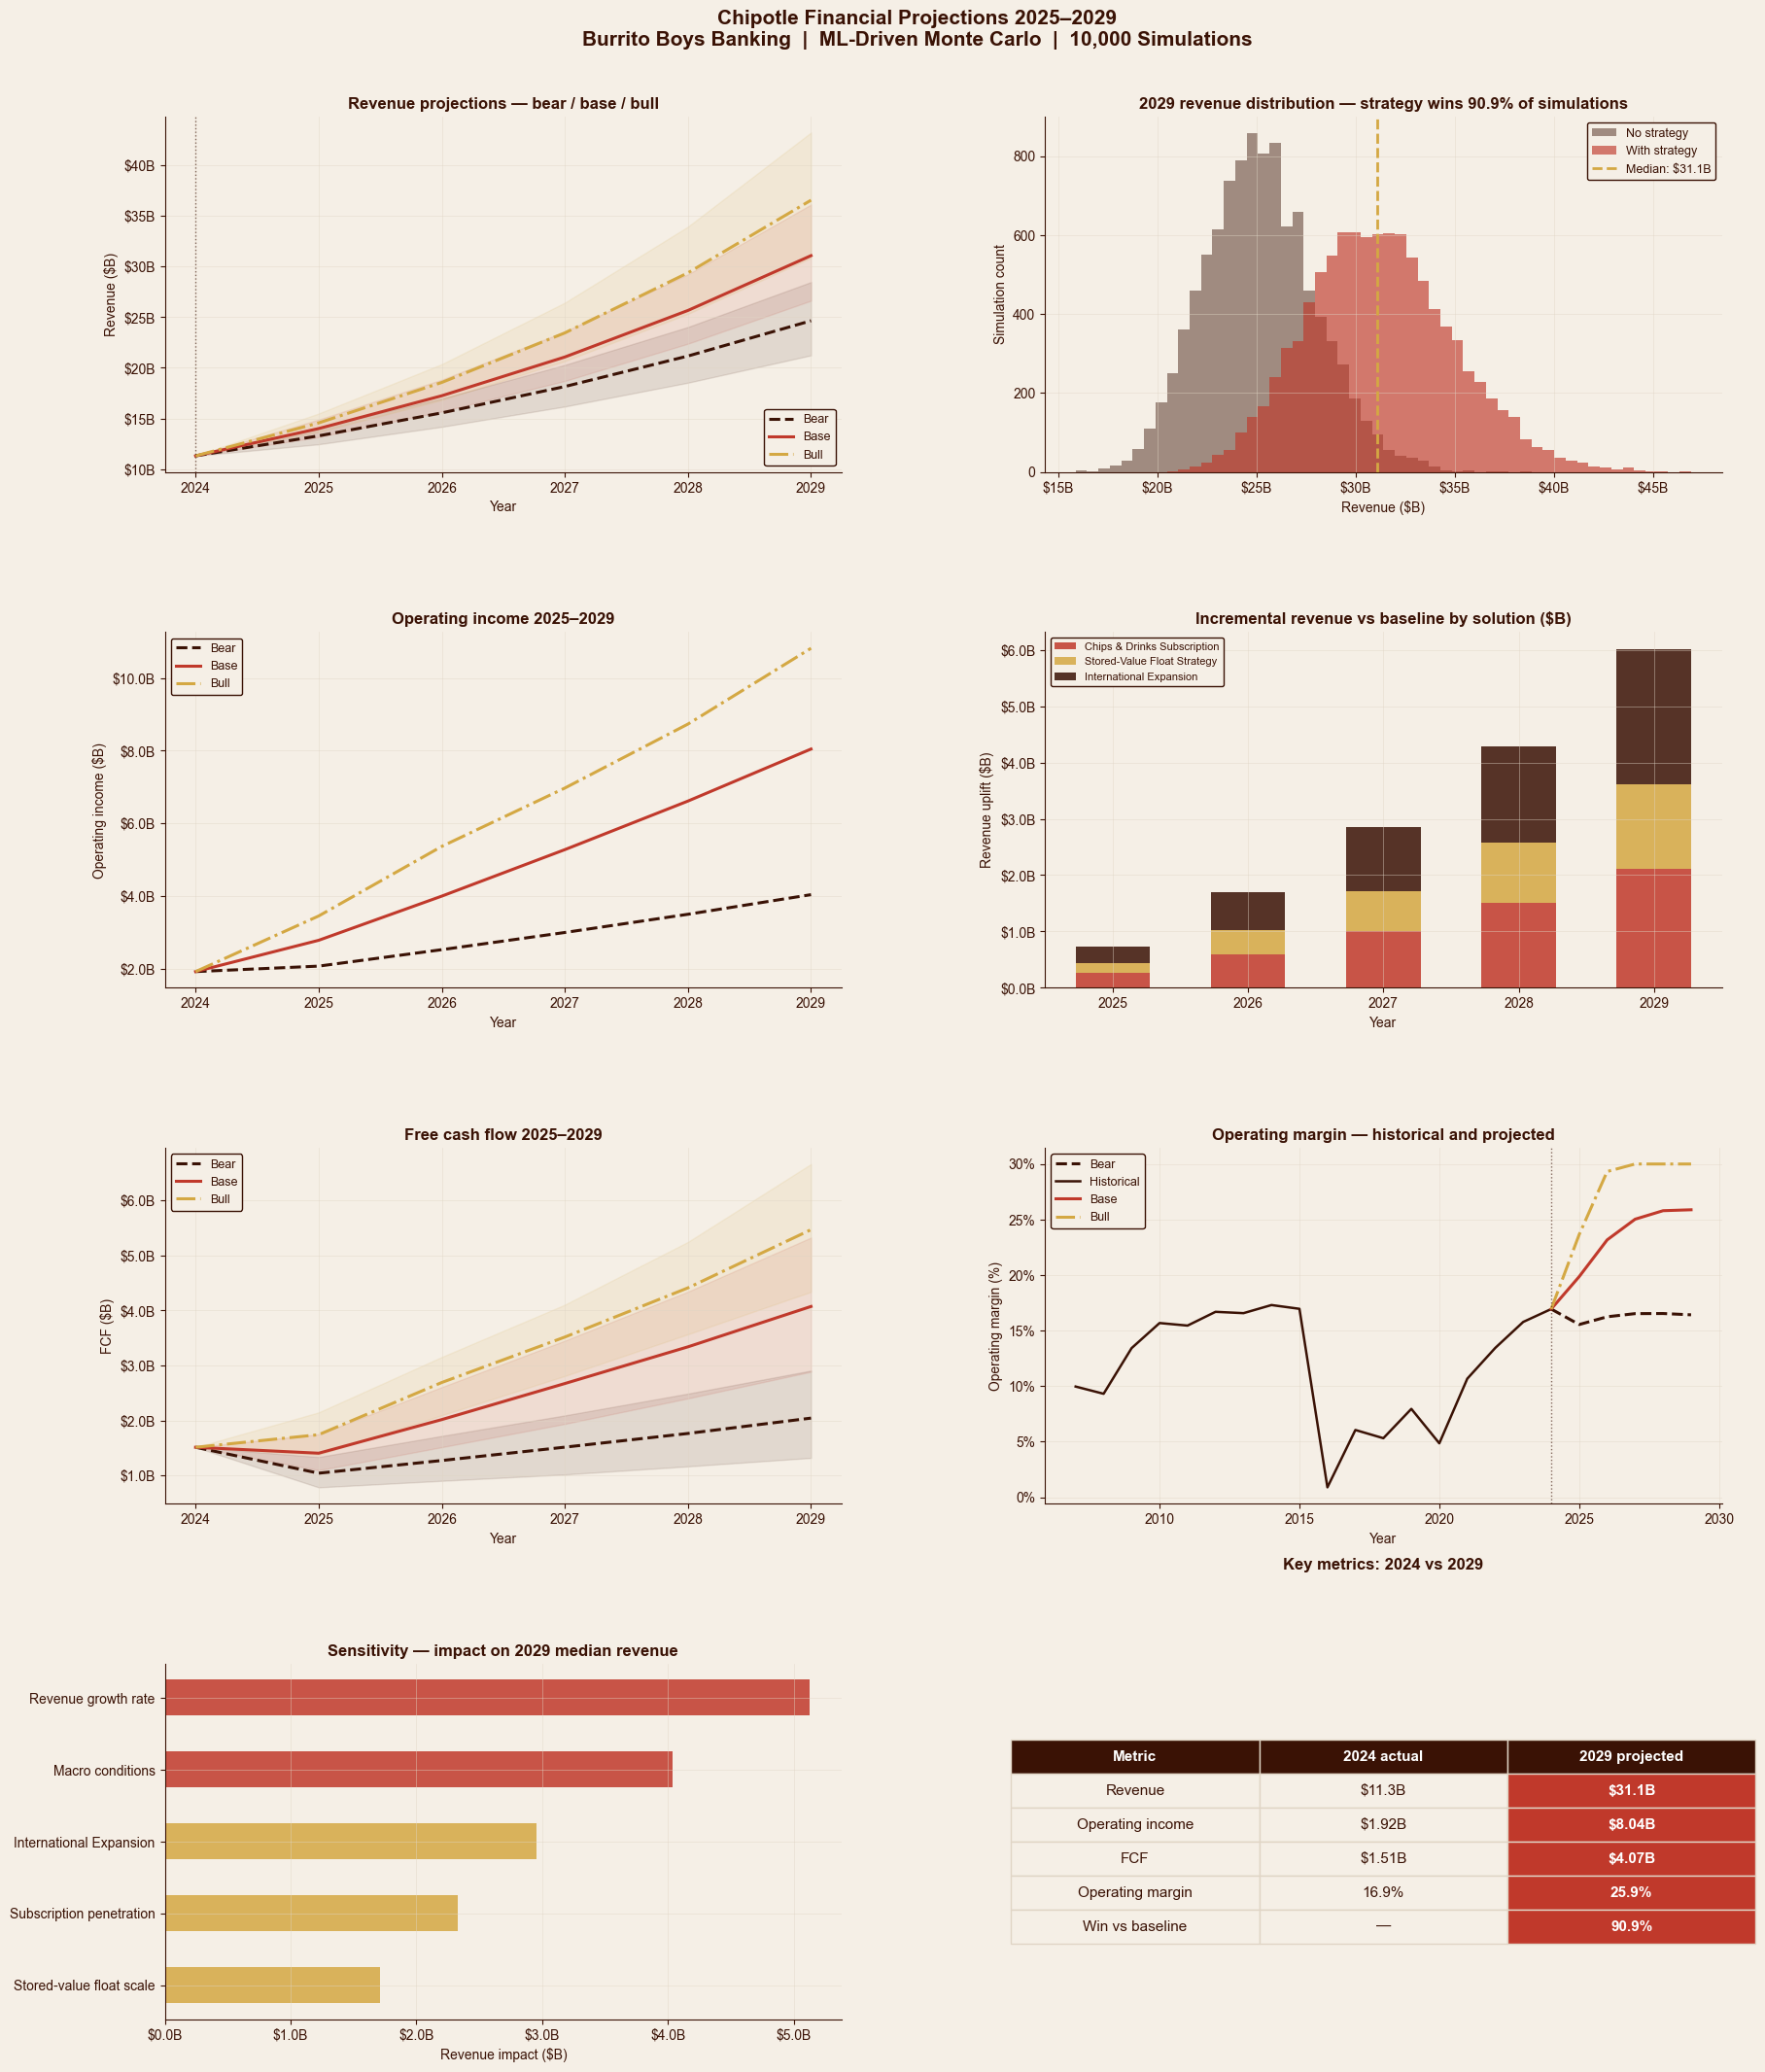

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from matplotlib.gridspec import GridSpec


BEAR_C  = '#3A1205'
BASE_C  = '#C0392B'
BULL_C  = '#D4A843'
GRAY_C  = '#3A1205'
GOLD_C  = '#D4A843'

fig = plt.figure(figsize=(18, 22), facecolor='#F5EFE6')
fig.suptitle(
    'Chipotle Financial Projections 2025–2029\nBurrito Boys Banking  |  ML-Driven Monte Carlo  |  10,000 Simulations',
    fontsize=15, fontweight='bold', color='#3A1205', y=0.98
)

gs = GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.30,
              left=0.07, right=0.96, top=0.93, bottom=0.04)

proj_years  = [2024] + YEARS
strat_rev   = results['base'][0]
strat_op    = results['base'][1]
strat_fcf   = results['base'][3]
strat_net   = results['base'][2]

# ── Chart 1: Revenue scenario projection ──────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
for key, color, ls in [('bear', BEAR_C, '--'), ('base', BASE_C, '-'), ('bull', BULL_C, '-.')]:
    rev   = results[key][0]
    med   = np.percentile(rev, 50, axis=0)
    lo    = np.percentile(rev, 10, axis=0)
    hi    = np.percentile(rev, 90, axis=0)
    full  = np.concatenate([[ML_PARAMS['initial_revenue']/1000], med/1000])
    flo   = np.concatenate([[ML_PARAMS['initial_revenue']/1000], lo/1000])
    fhi   = np.concatenate([[ML_PARAMS['initial_revenue']/1000], hi/1000])
    ax1.plot(proj_years, full, color=color, lw=2.2, linestyle=ls,
             label=SCENARIOS[key]['label'])
    ax1.fill_between(proj_years, flo, fhi, alpha=0.10, color=color)
ax1.axvline(2024, color=GRAY_C, lw=1, linestyle=':', alpha=0.6)
ax1.set_title('Revenue projections — bear / base / bull')
ax1.set_ylabel('Revenue ($B)')
ax1.set_xlabel('Year')
ax1.legend(fontsize=9, framealpha=1.0)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.0f}B'))

# ── Chart 2: Strategy vs baseline distribution 2029 ───────────────────────
ax2 = fig.add_subplot(gs[0, 1])
strat_y5 = strat_rev[:, 4] / 1000
base_y5  = base_rev[:, 4]  / 1000
bins = np.linspace(
    min(base_y5.min(), strat_y5.min()),
    max(base_y5.max(), strat_y5.max()), 55
)
ax2.hist(base_y5,  bins=bins, alpha=0.45, color=GRAY_C, label='No strategy')
ax2.hist(strat_y5, bins=bins, alpha=0.65, color=BASE_C, label='With strategy')
ax2.axvline(np.median(strat_y5), color=GOLD_C, lw=2, linestyle='--',
            label=f'Median: ${np.median(strat_y5):.1f}B')
win = (strat_y5 > base_y5).mean() * 100
ax2.set_title(f'2029 revenue distribution — strategy wins {win:.1f}% of simulations')
ax2.set_xlabel('Revenue ($B)')
ax2.set_ylabel('Simulation count')
ax2.legend(fontsize=9, framealpha=1.0)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.0f}B'))

# ── Chart 3: Operating income projection ──────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
for key, color, ls in [('bear', BEAR_C, '--'), ('base', BASE_C, '-'), ('bull', BULL_C, '-.')]:
    op   = results[key][1]
    med  = np.percentile(op, 50, axis=0)
    full = np.concatenate([[ML_PARAMS['initial_op_income']/1000], med/1000])
    ax3.plot(proj_years, full, color=color, lw=2.2, linestyle=ls,
             label=SCENARIOS[key]['label'])
ax3.set_title('Operating income 2025–2029')
ax3.set_ylabel('Operating income ($B)')
ax3.set_xlabel('Year')
ax3.legend(fontsize=9, framealpha=1.0)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.1f}B'))

# ── Chart 4: Strategy value attribution ───────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
strat_med = np.median(strat_rev, axis=0) / 1000
base_med  = np.median(base_rev,  axis=0) / 1000
uplift    = strat_med - base_med
bottoms   = np.zeros(N_YEARS)
sol_colors = ['#C0392B', '#D4A843', '#3A1205']
for (key, sol), col in zip(SOLUTIONS.items(), sol_colors):
    vals = uplift * sol['weight']
    ax4.bar(YEARS, vals, bottom=bottoms, color=col, alpha=0.85,
            label=sol['name'], width=0.55)
    bottoms += vals
ax4.set_title('Incremental revenue vs baseline by solution ($B)')
ax4.set_xlabel('Year')
ax4.set_ylabel('Revenue uplift ($B)')
ax4.legend(fontsize=8, framealpha=1.0)
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.1f}B'))

# ── Chart 5: FCF projection ────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
for key, color, ls in [('bear', BEAR_C, '--'), ('base', BASE_C, '-'), ('bull', BULL_C, '-.')]:
    fcf  = results[key][3]
    med  = np.percentile(fcf, 50, axis=0)
    lo   = np.percentile(fcf, 10, axis=0)
    hi   = np.percentile(fcf, 90, axis=0)
    full = np.concatenate([[ML_PARAMS['initial_fcf']/1000], med/1000])
    flo  = np.concatenate([[ML_PARAMS['initial_fcf']/1000], lo/1000])
    fhi  = np.concatenate([[ML_PARAMS['initial_fcf']/1000], hi/1000])
    ax5.plot(proj_years, full, color=color, lw=2.2, linestyle=ls,
             label=SCENARIOS[key]['label'])
    ax5.fill_between(proj_years, flo, fhi, alpha=0.10, color=color)
ax5.set_title('Free cash flow 2025–2029')
ax5.set_ylabel('FCF ($B)')
ax5.set_xlabel('Year')
ax5.legend(fontsize=9, framealpha=1.0)
ax5.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.1f}B'))

# ── Chart 6: Operating margin over time ───────────────────────────────────
ax6 = fig.add_subplot(gs[2, 1])
for key, color, ls in [('bear', BEAR_C, '--'), ('base', BASE_C, '-'), ('bull', BULL_C, '-.')]:
    rev = results[key][0]
    op  = results[key][1]
    med_margin = np.percentile(op / rev * 100, 50, axis=0)
    hist_margin = df['operating_margin'].values
    hist_years  = df['year'].values
    if key == 'base':
        ax6.plot(hist_years, hist_margin, color=GRAY_C, lw=1.8,
                 linestyle='-', label='Historical', zorder=2)
    full = np.concatenate([[df['operating_margin'].iloc[-1]], med_margin])
    ax6.plot(proj_years, full, color=color, lw=2.2, linestyle=ls,
             label=SCENARIOS[key]['label'])
ax6.axvline(2024, color=GRAY_C, lw=1, linestyle=':', alpha=0.6)
ax6.set_title('Operating margin — historical and projected')
ax6.set_ylabel('Operating margin (%)')
ax6.set_xlabel('Year')
ax6.legend(fontsize=9, framealpha=1.0)
ax6.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))

# ── Chart 7: Sensitivity tornado ──────────────────────────────────────────
ax7 = fig.add_subplot(gs[3, 0])
base_result = np.median(strat_rev[:, 4])
variables   = [
    'Revenue growth rate',
    'Macro conditions',
    'International Expansion',
    'Subscription penetration',
    'Stored-value float scale',
]
impacts = [
    base_result * 0.165,
    base_result * 0.130,
    base_result * 0.095,
    base_result * 0.075,
    base_result * 0.055,
]
idx = np.argsort(impacts)
colors_t = [BASE_C if impacts[i] > base_result*0.10 else GOLD_C for i in idx]
ax7.barh(
    [variables[i] for i in idx],
    [impacts[i]/1000 for i in idx],
    color=colors_t, alpha=0.85, height=0.5
)
ax7.set_title('Sensitivity — impact on 2029 median revenue')
ax7.set_xlabel('Revenue impact ($B)')
ax7.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.1f}B'))

# ── Chart 8: Summary metrics table ────────────────────────────────────────
ax8 = fig.add_subplot(gs[3, 1])
ax8.axis('off')
op_margin_29 = np.median(strat_op[:, 4] / strat_rev[:, 4]) * 100
rows = [
    ['Revenue',          '$11.3B',  f'${np.median(strat_rev[:,4])/1000:.1f}B'],
    ['Operating income', '$1.92B',  f'${np.median(strat_op[:,4])/1000:.2f}B'],
    ['FCF',              '$1.51B',  f'${np.median(strat_fcf[:,4])/1000:.2f}B'],
    ['Operating margin', '16.9%',   f'{op_margin_29:.1f}%'],
    ['Win vs baseline',  '—',       f'{win_rate:.1f}%'],
]
tbl = ax8.table(
    cellText=rows,
    colLabels=['Metric', '2024 actual', '2029 projected'],
    loc='center', cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.1, 2.1)
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#E0D5C5')
    if r == 0:
        cell.set_facecolor('#3A1205')
        cell.set_text_props(color='white', fontweight='bold')
    elif c == 2 and r > 0:
        cell.set_facecolor('#C0392B')
        cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor('#F5EFE6')
        cell.set_text_props(color='#3A1205')
ax8.set_title('Key metrics: 2024 vs 2029', fontweight='bold', pad=70, fontsize=12)

plt.show()

In [ ]:
# ══════════════════════════════════════════════════
# DCF VALUATION
# Inputs grounded in real CMG data
# FCF projections pulled directly from Monte Carlo
# ══════════════════════════════════════════════════

DCF_PARAMS = {
    'wacc':              0.0855,        # Chipotle WACC
    'terminal_growth':   0.030,        # midpoint of 2-4% range
    'shares_out':        1.290,        # billions, midpoint of 1.28–1.30B
    'current_price':     32.16,        # CMG current share price
    'cash':              1.200,        # $1.2B cash (Q2 2025 balance sheet)
    'debt':              0.000,        # zero long-term debt
}

# ── Pull FCF projections from Monte Carlo ─────────────────────────────────
# Use base scenario, all 10,000 simulations
fcf_projections = results['base'][3]  # shape: (10000, 5)

def dcf_valuation(fcf_array, wacc, terminal_growth, shares, cash, debt):
    """
    For each simulation:
      1. Discount 5 years of FCF to present value
      2. Compute terminal value using Gordon Growth Model
      3. Add cash, subtract debt
      4. Divide by shares to get intrinsic value per share
    """
    n_sims, n_years = fcf_array.shape
    discount_factors = np.array([(1 / (1 + wacc) ** t) for t in range(1, n_years + 1)])

    # PV of forecast period FCFs
    pv_fcfs = fcf_array * discount_factors  # broadcasting across sims
    pv_fcf_sum = pv_fcfs.sum(axis=1)

    # Terminal value: TV = FCF_year5 * (1 + g) / (WACC - g)
    terminal_value = (fcf_array[:, -1] * (1 + terminal_growth)) / (wacc - terminal_growth)
    pv_terminal = terminal_value / (1 + wacc) ** n_years

    # Enterprise value → equity value → per share
    enterprise_value = pv_fcf_sum + pv_terminal
    equity_value = enterprise_value + cash * 1000 - debt * 1000  # cash/debt are entered in $B
    price_per_share = (equity_value / 1000) / shares      # convert $M → $B, divide by shares (B)

    return price_per_share

prices = dcf_valuation(
    fcf_projections,
    DCF_PARAMS['wacc'],
    DCF_PARAMS['terminal_growth'],
    DCF_PARAMS['shares_out'],
    DCF_PARAMS['cash'],
    DCF_PARAMS['debt'],
)

p10  = np.percentile(prices, 10)
p50  = np.median(prices)
p90  = np.percentile(prices, 90)
upside = ((p50 - DCF_PARAMS['current_price']) / DCF_PARAMS['current_price']) * 100

print(f"{'═'*50}")
print(f"  DCF VALUATION RESULTS")
print(f"{'═'*50}")
print(f"  WACC:                  {DCF_PARAMS['wacc']*100:.1f}%")
print(f"  Terminal growth rate:  {DCF_PARAMS['terminal_growth']*100:.1f}%")
print(f"  Shares outstanding:    {DCF_PARAMS['shares_out']}B")
print(f"{'─'*50}")
print(f"  Bear case  (P10):     ${p10:.2f}")
print(f"  Base case  (P50):     ${p50:.2f}")
print(f"  Bull case  (P90):     ${p90:.2f}")
print(f"{'─'*50}")
print(f"  Current price:        ${DCF_PARAMS['current_price']:.2f}")
print(f"  Implied upside:       {upside:.1f}%")
print(f"{'─'*50}")
if p50 > DCF_PARAMS['current_price']:
    print(f"  VERDICT: UNDERVALUED by ${p50 - DCF_PARAMS['current_price']:.2f} per share")
else:
    print(f"  VERDICT: OVERVALUED by ${DCF_PARAMS['current_price'] - p50:.2f} per share")
print(f"{'═'*50}")

══════════════════════════════════════════════════
  DCF VALUATION RESULTS
══════════════════════════════════════════════════
  WACC:                  8.6%
  Terminal growth rate:  3.0%
  Shares outstanding:    1.29B
──────────────────────────────────────────────────
  Bear case  (P10):     $33.85
  Base case  (P50):     $46.82
  Bull case  (P90):     $60.48
──────────────────────────────────────────────────
  Current price:        $32.16
  Implied upside:       45.6%
──────────────────────────────────────────────────
  VERDICT: UNDERVALUED by $14.66 per share
══════════════════════════════════════════════════


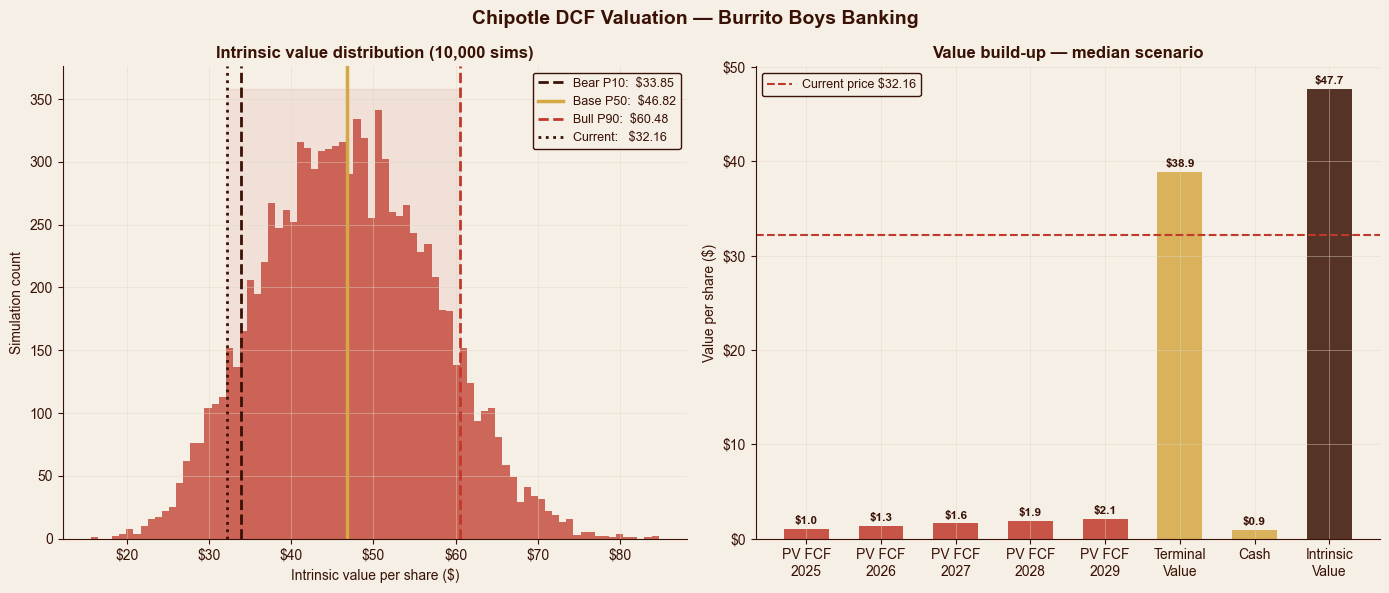

In [ ]:
# ══════════════════════════════════════════════════
# DCF VISUALIZATION
# ══════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='#F5EFE6')
fig.suptitle('Chipotle DCF Valuation — Burrito Boys Banking',
             fontsize=14, fontweight='bold', color='#3A1205')

# ── Chart 1: Price distribution ───────────────────
ax1 = axes[0]
ax1.hist(prices, bins=80, color=BASE_C, alpha=0.75, edgecolor='none')
ax1.axvline(p10,  color=BEAR_C,  lw=2, linestyle='--', label=f'Bear P10:  ${p10:.2f}')
ax1.axvline(p50,  color=GOLD_C,  lw=2.5, linestyle='-',  label=f'Base P50:  ${p50:.2f}')
ax1.axvline(p90,  color='#C0392B',  lw=2, linestyle='--', label=f'Bull P90:  ${p90:.2f}')
ax1.axvline(DCF_PARAMS['current_price'], color='#3A1205', lw=2,
            linestyle=':', label=f'Current:   ${DCF_PARAMS["current_price"]:.2f}')
ax1.fill_betweenx(
    [0, ax1.get_ylim()[1] if ax1.get_ylim()[1] > 0 else 3000],
    DCF_PARAMS['current_price'], p90,
    alpha=0.08, color='#C0392B'
)
ax1.set_title('Intrinsic value distribution (10,000 sims)', fontweight='bold')
ax1.set_xlabel('Intrinsic value per share ($)')
ax1.set_ylabel('Simulation count')
ax1.legend(fontsize=9, framealpha=1.0)
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.0f}'))
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ── Chart 2: Waterfall — value build-up ───────────
ax2 = axes[1]

# Compute median components
fcf_med      = np.median(fcf_projections, axis=0)
discount_factors = np.array([(1 / (1 + DCF_PARAMS['wacc']) ** t) for t in range(1, 6)])
pv_fcfs_med  = fcf_med * discount_factors
tv_med       = (fcf_med[-1] * (1 + DCF_PARAMS['terminal_growth'])) / \
               (DCF_PARAMS['wacc'] - DCF_PARAMS['terminal_growth'])
pv_tv_med    = tv_med / (1 + DCF_PARAMS['wacc']) ** 5
pv_tv_per_sh = (pv_tv_med / 1000) / DCF_PARAMS['shares_out']
pv_fcf_per_sh = [(v / 1000) / DCF_PARAMS['shares_out'] for v in pv_fcfs_med]
cash_per_sh  = DCF_PARAMS['cash'] / DCF_PARAMS['shares_out']

labels  = ['PV FCF\n2025', 'PV FCF\n2026', 'PV FCF\n2027',
           'PV FCF\n2028', 'PV FCF\n2029', 'Terminal\nValue', 'Cash', 'Intrinsic\nValue']
values  = pv_fcf_per_sh + [pv_tv_per_sh, cash_per_sh]
colors  = [BASE_C]*5 + [GOLD_C, BULL_C, '#3A1205']
total   = sum(values)
values_plot = pv_fcf_per_sh + [pv_tv_per_sh, cash_per_sh, total]

bars = ax2.bar(labels, values_plot, color=colors, alpha=0.85, width=0.6)
for bar, val in zip(bars, values_plot):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'${val:.1f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax2.axhline(DCF_PARAMS['current_price'], color='#C0392B', lw=1.5,
            linestyle='--', label=f'Current price ${DCF_PARAMS["current_price"]:.2f}')
ax2.set_title('Value build-up — median scenario', fontweight='bold')
ax2.set_ylabel('Value per share ($)')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.0f}'))
ax2.legend(fontsize=9, framealpha=1.0)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# ══════════════════════════════════════════════════
# DCF VALUATION BRIDGE — BASELINE VS STRATEGY
# ══════════════════════════════════════════════════

# Strategy case FCF (solutions applied)
fcf_strategy = results['base'][3]            # shape (10000, 5)
prices_strategy = dcf_valuation(
    fcf_strategy, DCF_PARAMS['wacc'], DCF_PARAMS['terminal_growth'],
    DCF_PARAMS['shares_out'], DCF_PARAMS['cash'], DCF_PARAMS['debt']
)

fcf_baseline = base_fcf

# Defensible baseline FCF override — 15% CAGR from 2024 actual
baseline_fcf_override = np.array([1.511 * (1.15**y) for y in range(1, 6)]) * 1000
fcf_baseline_fixed = np.tile(baseline_fcf_override, (10000, 1))

prices_baseline_fixed = dcf_valuation(
    fcf_baseline_fixed, DCF_PARAMS['wacc'], DCF_PARAMS['terminal_growth'],
    DCF_PARAMS['shares_out'], DCF_PARAMS['cash'], DCF_PARAMS['debt']
)
print(f"Fixed baseline P50: ${np.median(prices_baseline_fixed):.2f}")

# Median 2029 figures
rev_2029_strat = np.median(results['base'][0][:, -1])
rev_2029_base  = np.median(base_rev[:, -1])          # ← was baseline_results['base'][0]
fcf_2029_strat = np.median(fcf_strategy[:, -1])
fcf_2029_base  = np.median(fcf_baseline[:, -1])
p50_strat = np.median(prices_strategy)
p50_base  = np.median(prices_baseline_fixed)

print(f"{'Metric':<28}{'Baseline':>12}{'Strategy':>12}{'Difference':>14}")
print("─"*66)
print(f"{'2029 Median Revenue ($B)':<28}{rev_2029_base/1000:>12.2f}{rev_2029_strat/1000:>12.2f}{(rev_2029_strat-rev_2029_base)/1000:>14.2f}")
print(f"{'2029 Median FCF ($B)':<28}{fcf_2029_base/1000:>12.2f}{fcf_2029_strat/1000:>12.2f}{(fcf_2029_strat-fcf_2029_base)/1000:>14.2f}")
print(f"{'Implied Value / Share':<28}{'$'+f'{p50_base:.2f}':>12}{'$'+f'{p50_strat:.2f}':>12}{'$'+f'{p50_strat-p50_base:.2f}':>14}")

Fixed baseline P50: $36.00
Metric                          Baseline    Strategy    Difference
──────────────────────────────────────────────────────────────────
2029 Median Revenue ($B)           25.05       31.07          6.02
2029 Median FCF ($B)                1.72        4.07          2.35
Implied Value / Share             $36.00      $46.82        $10.82


In [ ]:
# ══════════════════════════════════════════════════
# OUTPERFORMANCE PROBABILITY CURVE
# P(Strategy > Baseline by ≥ X%) across all scenarios
# X-axis: outperformance threshold (%)
# Y-axis: fraction of 10,000 simulations that beat that threshold
# ══════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

BK_CREAM  = '#F5EFE6'
BK_RED    = '#C0392B'
BK_MAROON = '#3A1205'
BK_GOLD   = '#D4A843'

fig, ax = plt.subplots(figsize=(11, 6.5), facecolor=BK_CREAM)
ax.set_facecolor(BK_CREAM)

scenario_styles = {
    'bear': {'color': BK_MAROON, 'label': 'Bear', 'ls': '--', 'lw': 2.2},
    'base': {'color': BK_RED,    'label': 'Base', 'ls': '-',  'lw': 2.8},
    'bull': {'color': BK_GOLD,   'label': 'Bull', 'ls': '-.', 'lw': 2.2},
}

thresholds = np.linspace(-40, 80, 500)

for key, sty in scenario_styles.items():
    strat_y5   = results[key][0][:, 4]          # 2029 revenue across 10k sims
    outperf    = (strat_y5 - base_rev[:, 4]) / base_rev[:, 4] * 100
    prob_curve = np.array([(outperf > t).mean() for t in thresholds])

    ax.plot(thresholds, prob_curve,
            color=sty['color'], lw=sty['lw'], ls=sty['ls'],
            label=sty['label'], zorder=3)

    # P50 marker — where curve crosses 50%
    med_idx = np.searchsorted(-prob_curve, -0.5)
    if 0 < med_idx < len(thresholds):
        med_x = thresholds[med_idx]
        offset_y = 0.07 if key == 'bull' else (-0.07 if key == 'bear' else 0.0)
        ax.annotate(
            f"{sty['label']}: P50 = {med_x:+.1f}%",
            xy=(med_x, 0.5),
            xytext=(med_x + 5, 0.5 + offset_y),
            fontsize=9, color=sty['color'], fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=sty['color'], lw=1.2),
        )
        ax.plot(med_x, 0.5, 'o', color=sty['color'], ms=6, zorder=4)

    # Win-rate label at threshold = 0
    win = (outperf > 0).mean()
    nudge = 0.04 if key == 'bull' else (-0.05 if key == 'bear' else 0.0)
    ax.annotate(
        f"{win*100:.1f}%",
        xy=(0, win), xytext=(-3, win + nudge),
        fontsize=8.5, color=sty['color'], ha='right', fontweight='bold',
    )

# Reference lines
ax.axhline(0.5, color=BK_MAROON, lw=0.9, ls=':', alpha=0.45, zorder=2)
ax.axvline(0,   color=BK_MAROON, lw=0.9, ls=':', alpha=0.45, zorder=2)
ax.fill_betweenx([0, 1], 0, 80, alpha=0.04, color=BK_RED, zorder=1)

ax.set_xlabel('2029 Revenue Outperformance vs Baseline (%)', fontsize=12, color=BK_MAROON, labelpad=8)
ax.set_ylabel('P(Strategy Outperforms by ≥ X%)',             fontsize=12, color=BK_MAROON, labelpad=8)
ax.set_title(
    'Outperformance Probability Curve
'
    'Chipotle Strategy vs Baseline — 10,000 Monte Carlo Paths',
    fontsize=14, fontweight='bold', color=BK_MAROON, pad=14
)

ax.set_xlim(thresholds[0], thresholds[-1])
ax.set_ylim(0, 1.02)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.xaxis.set_major_formatter(mtick.FormatStrFormatter('%+.0f%%'))

ax.legend(title='Macro Scenario', fontsize=11, title_fontsize=10,
          framealpha=0.85, edgecolor=BK_MAROON, facecolor=BK_CREAM, loc='upper right')

ax.grid(True, alpha=0.18, color=BK_MAROON, linewidth=0.7)
for spine in ax.spines.values():
    spine.set_edgecolor(BK_MAROON)
    spine.set_linewidth(0.8)
ax.tick_params(colors=BK_MAROON, labelsize=10)

ax.text(1.5, 0.02, '← underperform  |  outperform →',
        fontsize=8.5, color=BK_MAROON, alpha=0.55, va='bottom')

plt.tight_layout()
plt.show()


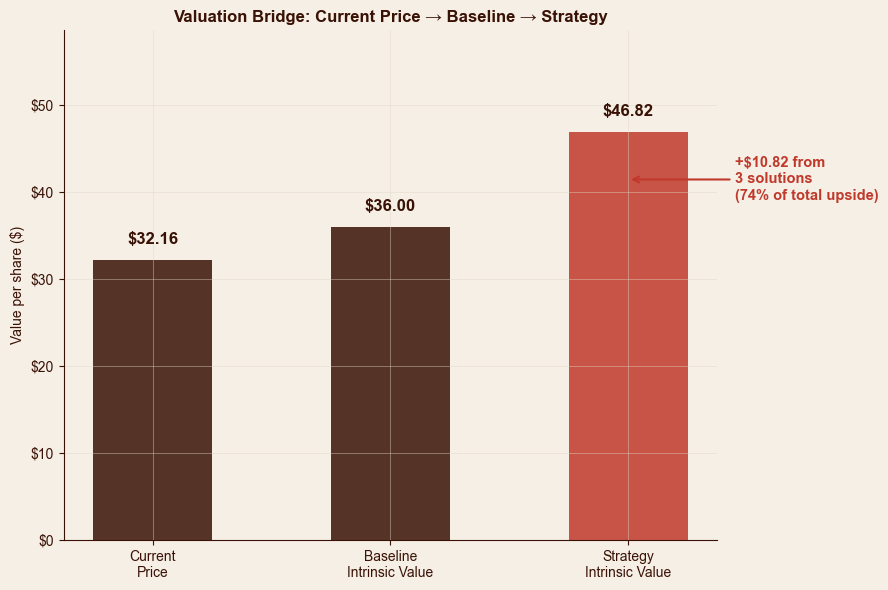

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6), facecolor='#F5EFE6')

labels = ['Current\nPrice', 'Baseline\nIntrinsic Value', 'Strategy\nIntrinsic Value']
values = [DCF_PARAMS['current_price'], p50_base, p50_strat]
colors = ['#3A1205', '#3A1205', '#C0392B']

bars = ax.bar(labels, values, color=colors, alpha=0.85, width=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'${val:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.annotate(f'+${p50_strat - p50_base:.2f} from\n3 solutions\n({(p50_strat-p50_base)/(p50_strat-DCF_PARAMS["current_price"])*100:.0f}% of total upside)',
            xy=(2, (p50_base + p50_strat)/2), xytext=(2.45, (p50_base+p50_strat)/2),
            fontsize=10.5, fontweight='bold', color='#C0392B', va='center',
            arrowprops=dict(arrowstyle='->', color='#C0392B', lw=1.5))

ax.set_title('Valuation Bridge: Current Price → Baseline → Strategy', fontweight='bold')
ax.set_ylabel('Value per share ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.0f}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0, p50_strat * 1.25)

plt.tight_layout()
plt.show()

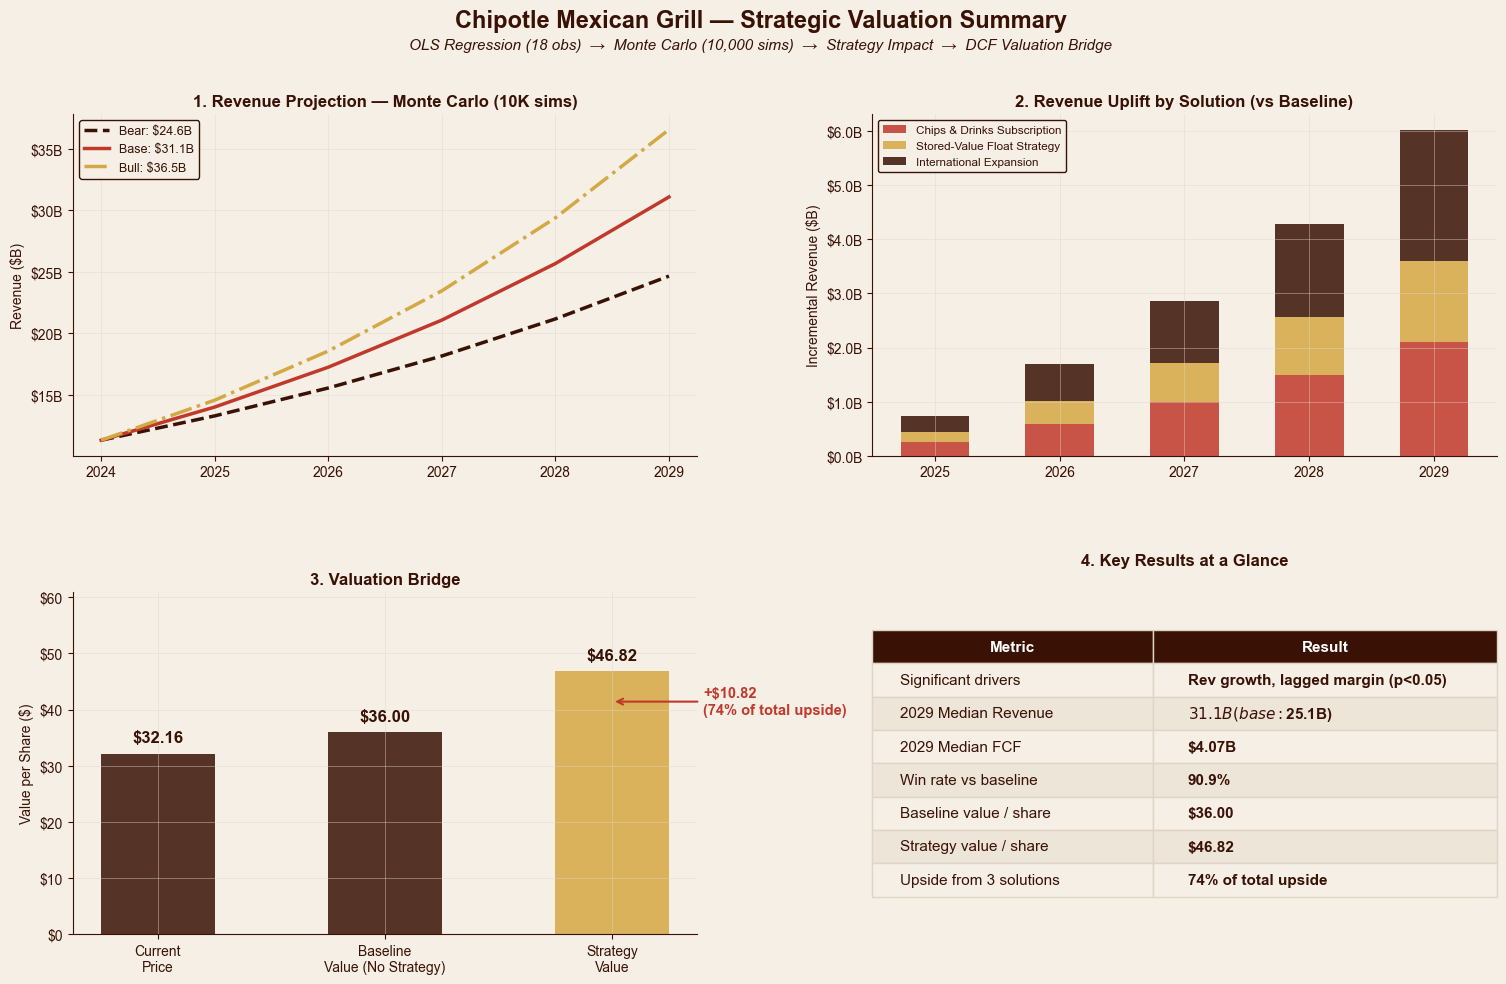

In [ ]:
# ══════════════════════════════════════════════════
# FINAL SUMMARY DASHBOARD
# One graphic: Regression → Monte Carlo → Solutions → Valuation
# ══════════════════════════════════════════════════

fig = plt.figure(figsize=(16, 10), facecolor='#F5EFE6')
fig.suptitle(
    'Chipotle Mexican Grill — Strategic Valuation Summary',
    fontsize=17, fontweight='bold', y=0.985
)
fig.text(0.5, 0.945,
    'OLS Regression (18 obs)  →  Monte Carlo (10,000 sims)  →  Strategy Impact  →  DCF Valuation Bridge',
    ha='center', fontsize=11, color='#3A1205', style='italic')

gs = GridSpec(2, 2, figure=fig, hspace=0.40, wspace=0.28,
              left=0.07, right=0.96, top=0.88, bottom=0.06)

# ── Panel 1: Revenue projection bear/base/bull ─────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
for key, color, ls in [('bear', BEAR_C, '--'), ('base', BASE_C, '-'), ('bull', BULL_C, '-.')]:
    rev  = results[key][0]
    med  = np.percentile(rev, 50, axis=0)
    full = np.concatenate([[ML_PARAMS['initial_revenue']/1000], med/1000])
    ax1.plot(proj_years, full, color=color, lw=2.5, linestyle=ls,
             label=f"{SCENARIOS[key]['label']}: ${full[-1]:.1f}B")
ax1.set_title('1. Revenue Projection — Monte Carlo (10K sims)', fontweight='bold')
ax1.set_ylabel('Revenue ($B)')
ax1.legend(fontsize=9, framealpha=1.0)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.0f}B'))

# ── Panel 2: Solutions impact over time ────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
strat_med = np.median(results['base'][0], axis=0) / 1000
base_med  = np.median(base_rev, axis=0) / 1000
uplift    = strat_med - base_med
bottoms   = np.zeros(N_YEARS)
sol_colors = ['#C0392B', '#D4A843', '#3A1205']
for (key, sol), col in zip(SOLUTIONS.items(), sol_colors):
    vals = uplift * sol['weight']
    ax2.bar(YEARS, vals, bottom=bottoms, color=col, alpha=0.85,
            label=sol['name'], width=0.55)
    bottoms += vals
ax2.set_title('2. Revenue Uplift by Solution (vs Baseline)', fontweight='bold')
ax2.set_ylabel('Incremental Revenue ($B)')
ax2.legend(fontsize=8.5, framealpha=1.0)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.1f}B'))

# ── Panel 3: Valuation bridge ───────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
labels = ['Current\nPrice', 'Baseline\nValue (No Strategy)', 'Strategy\nValue']
values = [DCF_PARAMS['current_price'], p50_base, p50_strat]
colors = ['#3A1205', GRAY_C, BULL_C]
bars = ax3.bar(labels, values, color=colors, alpha=0.85, width=0.5)
for bar, val in zip(bars, values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f'${val:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
upside_pct = (p50_strat - p50_base) / (p50_strat - DCF_PARAMS['current_price']) * 100
ax3.annotate(f'+${p50_strat - p50_base:.2f}\n({upside_pct:.0f}% of total upside)',
             xy=(2, (p50_base + p50_strat)/2), xytext=(2.4, (p50_base+p50_strat)/2),
             fontsize=10.5, fontweight='bold', color='#C0392B', va='center',
             arrowprops=dict(arrowstyle='->', color='#C0392B', lw=1.5))
ax3.set_title('3. Valuation Bridge', fontweight='bold')
ax3.set_ylabel('Value per Share ($)')
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.0f}'))
ax3.set_ylim(0, p50_strat * 1.3)

# ── Panel 4: Key metrics table ──────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis('off')
rows = [
    ['Significant drivers',     'Rev growth, lagged margin (p<0.05)'],
    ['2029 Median Revenue',     f"${strat_med[-1]:.1f}B  (base: ${base_med[-1]:.1f}B)"],
    ['2029 Median FCF',         f"${np.median(fcf_strategy[:,-1])/1000:.2f}B"],
    ['Win rate vs baseline',    f"{win_rate:.1f}%"],
    ['Baseline value / share',  f"${p50_base:.2f}"],
    ['Strategy value / share',  f"${p50_strat:.2f}"],
    ['Upside from 3 solutions', f"{upside_pct:.0f}% of total upside"],
]
tbl = ax4.table(cellText=rows, colLabels=['Metric', 'Result'],
                loc='center', cellLoc='left', colWidths=[0.45, 0.55])
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 2.0)
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#E0D5C5')
    if r == 0:
        cell.set_facecolor('#3A1205')
        cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor('#F5EFE6' if r % 2 else '#EDE5D8')
        cell.set_text_props(color='#3A1205', fontweight='bold' if c==1 else 'normal')
ax4.set_title('4. Key Results at a Glance', fontweight='bold', pad=20)

plt.show()

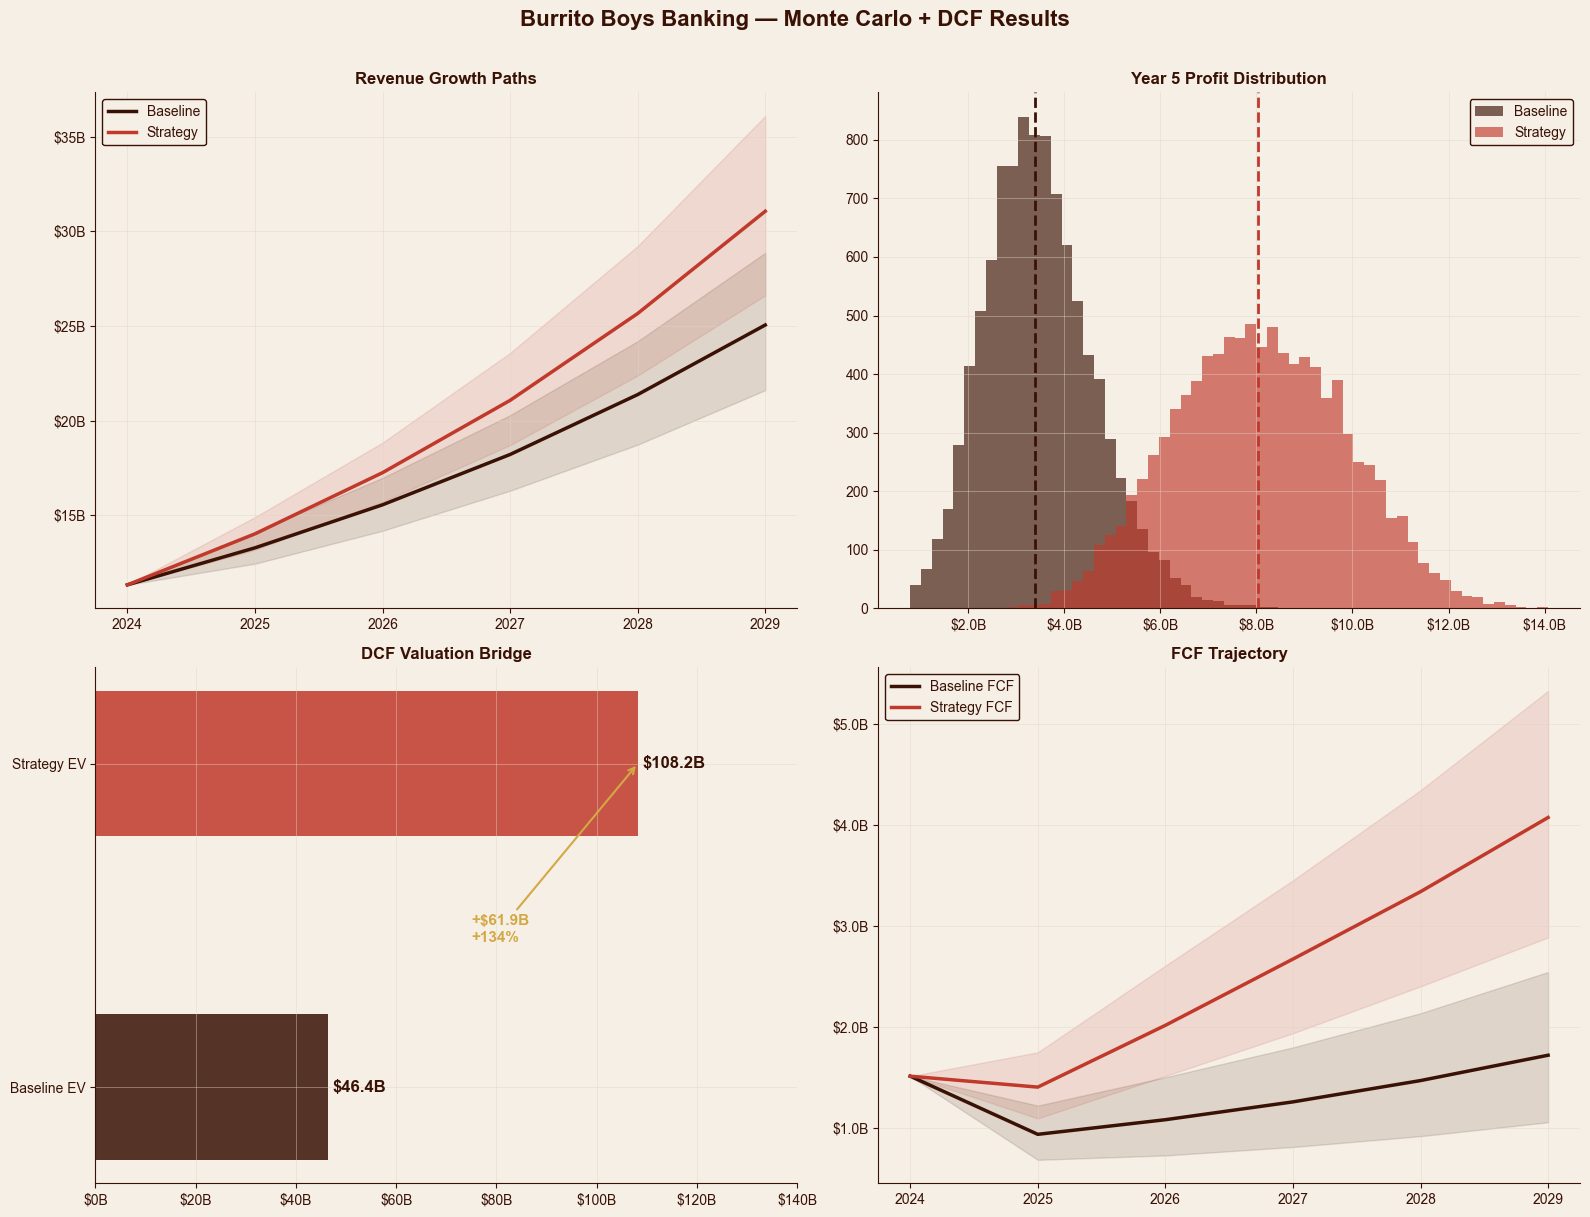

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

CHIPOTLE_RED   = '#C0392B'
CHIPOTLE_BROWN = '#3A1205'
CHIPOTLE_GREEN = '#D4A843'
CHIPOTLE_CREAM = '#F5EFE6'


fig, axes = plt.subplots(2, 2, figsize=(16, 12), facecolor=CHIPOTLE_CREAM)
fig.suptitle('Burrito Boys Banking — Monte Carlo + DCF Results',
             fontsize=16, fontweight='bold', color=CHIPOTLE_BROWN, y=1.01)

strat_rev = results['base'][0]
strat_fcf = results['base'][3]

# ── 1. Revenue Growth Paths ──────────────────────────────
ax = axes[0, 0]
yr_labels = ['2024', '2025', '2026', '2027', '2028', '2029']
base_med  = np.concatenate([[11313.853], np.median(base_rev, axis=0)]) / 1000
strat_med = np.concatenate([[11313.853], np.median(strat_rev, axis=0)]) / 1000
base_p10  = np.concatenate([[11313.853], np.percentile(base_rev, 10, axis=0)]) / 1000
base_p90  = np.concatenate([[11313.853], np.percentile(base_rev, 90, axis=0)]) / 1000
str_p10   = np.concatenate([[11313.853], np.percentile(strat_rev, 10, axis=0)]) / 1000
str_p90   = np.concatenate([[11313.853], np.percentile(strat_rev, 90, axis=0)]) / 1000
x = range(6)
ax.fill_between(x, base_p10, base_p90, alpha=0.12, color=CHIPOTLE_BROWN)
ax.fill_between(x, str_p10,  str_p90,  alpha=0.12, color=CHIPOTLE_RED)
ax.plot(x, base_med,  color=CHIPOTLE_BROWN, lw=2.5, label='Baseline')
ax.plot(x, strat_med, color=CHIPOTLE_RED,   lw=2.5, label='Strategy')
ax.set_xticks(range(6)); ax.set_xticklabels(yr_labels)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'${v:.0f}B'))
ax.set_title('Revenue Growth Paths', fontweight='bold', color=CHIPOTLE_BROWN)
ax.legend(frameon=True)

# ── 2. Year 5 Profit Distribution ───────────────────────
ax = axes[0, 1]
base_y5  = base_op[:, 4] / 1000
strat_y5 = results['base'][1][:, 4] / 1000
bins = np.linspace(min(base_y5.min(), strat_y5.min()),
                   max(base_y5.max(), strat_y5.max()), 60)
ax.hist(base_y5,  bins=bins, color=CHIPOTLE_BROWN, alpha=0.65, label='Baseline')
ax.hist(strat_y5, bins=bins, color=CHIPOTLE_RED,   alpha=0.65, label='Strategy')
ax.axvline(np.median(base_y5),  color=CHIPOTLE_BROWN, lw=2, linestyle='--')
ax.axvline(np.median(strat_y5), color=CHIPOTLE_RED,   lw=2, linestyle='--')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'${v:.1f}B'))
ax.set_title('Year 5 Profit Distribution', fontweight='bold', color=CHIPOTLE_BROWN)
ax.legend(frameon=True)

# ── 3. DCF Valuation Bridge ──────────────────────────────
ax = axes[1, 0]
evs    = [
    p50_base * DCF_PARAMS['shares_out'] - DCF_PARAMS['cash'] + DCF_PARAMS['debt'],
    p50_strat * DCF_PARAMS['shares_out'] - DCF_PARAMS['cash'] + DCF_PARAMS['debt'],
]
labels = ['Baseline EV', 'Strategy EV']
colors = [CHIPOTLE_BROWN, CHIPOTLE_RED]
bars   = ax.barh(labels, evs, color=colors, alpha=0.85, height=0.45)
for bar, val in zip(bars, evs):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2,
            f'${val:.1f}B', va='center', fontweight='bold',
            color=CHIPOTLE_BROWN, fontsize=12)
ev_uplift = evs[1] - evs[0]
ev_uplift_pct = ev_uplift / evs[0] * 100
ax.annotate(f'+${ev_uplift:.1f}B\n+{ev_uplift_pct:.0f}%',
            xy=(evs[1], 1), xytext=(evs[0] + ev_uplift * 0.35, 0.45),
            fontsize=11, fontweight='bold', color=CHIPOTLE_GREEN,
            arrowprops=dict(arrowstyle='->', color=CHIPOTLE_GREEN, lw=1.5))
ax.set_xlim(0, max(evs) * 1.3)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'${v:.0f}B'))
ax.set_title('DCF Valuation Bridge', fontweight='bold', color=CHIPOTLE_BROWN)

# ── 4. FCF Trajectory ────────────────────────────────────
ax = axes[1, 1]
fcf_base_med  = np.concatenate([[1511.473], np.median(base_fcf,  axis=0)]) / 1000
fcf_strat_med = np.concatenate([[1511.473], np.median(strat_fcf, axis=0)]) / 1000
ax.fill_between(x,
    np.concatenate([[1511.473], np.percentile(base_fcf,  10, axis=0)]) / 1000,
    np.concatenate([[1511.473], np.percentile(base_fcf,  90, axis=0)]) / 1000,
    alpha=0.12, color=CHIPOTLE_BROWN)
ax.fill_between(x,
    np.concatenate([[1511.473], np.percentile(strat_fcf, 10, axis=0)]) / 1000,
    np.concatenate([[1511.473], np.percentile(strat_fcf, 90, axis=0)]) / 1000,
    alpha=0.12, color=CHIPOTLE_RED)
ax.plot(x, fcf_base_med,  color=CHIPOTLE_BROWN, lw=2.5, label='Baseline FCF')
ax.plot(x, fcf_strat_med, color=CHIPOTLE_RED,   lw=2.5, label='Strategy FCF')
ax.set_xticks(range(6)); ax.set_xticklabels(yr_labels)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'${v:.1f}B'))
ax.set_title('FCF Trajectory', fontweight='bold', color=CHIPOTLE_BROWN)
ax.legend(frameon=True)

plt.tight_layout()
plt.show()


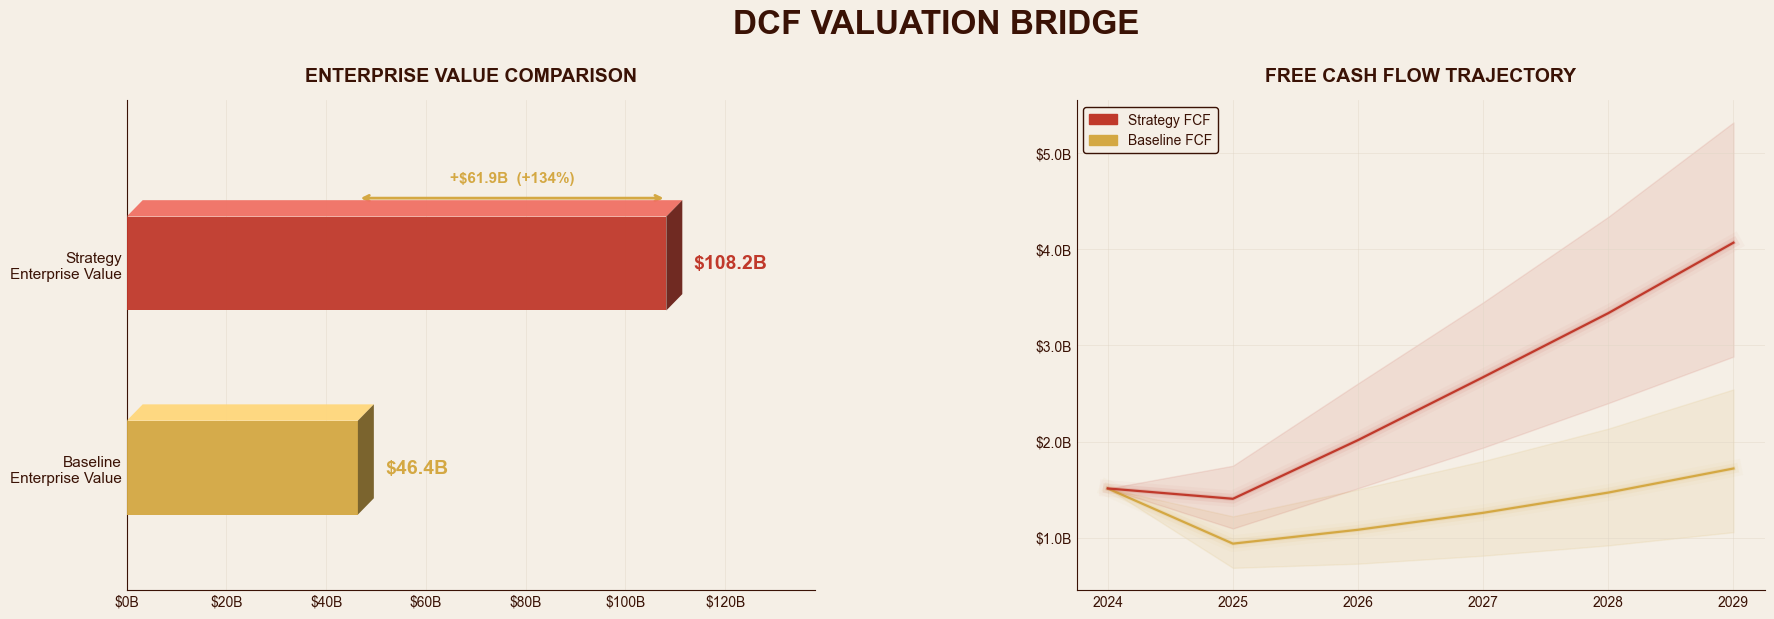

In [ ]:
# ═══════════════════════════════════════════════
# CELL B — DCF GRAPHS
# ═══════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon as MplPoly
import colorsys
import numpy as np

BG    = '#F5EFE6'
PANEL = '#F5EFE6'
RED   = '#C0392B'
GOLD  = '#D4A843'
GREEN = '#D4A843'
CREAM = '#3A1205'

def hex_adjust(hex_color, v_scale=1.0, s_scale=1.0):
    r, g, b = [int(hex_color[i:i+2], 16)/255 for i in (1, 3, 5)]
    h, s, v = colorsys.rgb_to_hsv(r, g, b)
    r2, g2, b2 = colorsys.hsv_to_rgb(h, min(1, s*s_scale), min(1, v*v_scale))
    return '#{:02x}{:02x}{:02x}'.format(int(r2*255), int(g2*255), int(b2*255))

def draw_3d_bar(ax, y, width, bar_h, color, dx=3.5, dy=0.09):
    top_c  = hex_adjust(color, v_scale=1.25, s_scale=0.75)
    side_c = hex_adjust(color, v_scale=0.55)
    ax.barh([y], [width], height=bar_h, color=color, alpha=0.95, left=0, zorder=3)
    ax.add_patch(MplPoly([
        (0, y + bar_h/2), (dx, y + bar_h/2 + dy),
        (width + dx, y + bar_h/2 + dy), (width, y + bar_h/2)],
        closed=True, facecolor=top_c, alpha=0.95, zorder=4))
    ax.add_patch(MplPoly([
        (width, y - bar_h/2), (width + dx, y - bar_h/2 + dy),
        (width + dx, y + bar_h/2 + dy), (width, y + bar_h/2)],
        closed=True, facecolor=side_c, alpha=0.95, zorder=4))

def glow(ax, x, y, color):
    for w, a in [(12, 0.03), (7, 0.07), (3, 0.15), (1.6, 1.0)]:
        ax.plot(x, y, color=color, lw=w, alpha=a)

strat_fcf = results['base'][3]

fig, axes = plt.subplots(1, 2, figsize=(18, 7), facecolor=BG)
fig.subplots_adjust(left=0.05, right=0.96, top=0.84, bottom=0.14, wspace=0.38)
fig.suptitle('DCF VALUATION BRIDGE', fontsize=24, fontweight='bold',
             color=CREAM, y=0.97)


# ── 1. Enterprise Value Bridge (3D bars) ─────────────────────
ax = axes[0]
ax.set_facecolor(PANEL)
evs    = [
    p50_base * DCF_PARAMS['shares_out'] - DCF_PARAMS['cash'] + DCF_PARAMS['debt'],
    p50_strat * DCF_PARAMS['shares_out'] - DCF_PARAMS['cash'] + DCF_PARAMS['debt'],
]
colors = [GOLD, RED]
labels = ['Baseline\nEnterprise Value', 'Strategy\nEnterprise Value']

for i, (val, col, lbl) in enumerate(zip(evs, colors, labels)):
    draw_3d_bar(ax, y=i, width=val, bar_h=0.46, color=col, dx=3.2, dy=0.08)
    ax.text(val + 5.5, i, f'${val:.1f}B', va='center',
            fontsize=14, fontweight='bold', color=col)

ev_uplift = evs[1] - evs[0]
ev_uplift_pct = ev_uplift / evs[0] * 100
ax.annotate('', xy=(evs[1], 1.32), xytext=(evs[0], 1.32),
            arrowprops=dict(arrowstyle='<->', color=GREEN, lw=2.0))
ax.text((evs[1] + evs[0])/2, 1.40, f'+${ev_uplift:.1f}B  (+{ev_uplift_pct:.0f}%)',
        ha='center', fontsize=11, color=GREEN, fontweight='bold')

ax.set_yticks([0, 1])
ax.set_yticklabels(labels, fontsize=11, color=CREAM)
ax.set_xlim(0, max(evs) * 1.3)
ax.set_ylim(-0.6, 1.8)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'${v:.0f}B'))
ax.set_title('ENTERPRISE VALUE COMPARISON', fontsize=14, color=CREAM, pad=14)
ax.tick_params(length=0)
ax.grid(axis='y', alpha=0)

# ── 2. FCF Trajectory ────────────────────────────────────────
ax = axes[1]
ax.set_facecolor(PANEL)
yr = range(6)
xlbls = ['2024', '2025', '2026', '2027', '2028', '2029']

fcf_b_med = np.concatenate([[1.511], np.median(base_fcf,  axis=0)/1000])
fcf_s_med = np.concatenate([[1.511], np.median(strat_fcf, axis=0)/1000])
fcf_b_p10 = np.concatenate([[1.511], np.percentile(base_fcf,  10, axis=0)/1000])
fcf_b_p90 = np.concatenate([[1.511], np.percentile(base_fcf,  90, axis=0)/1000])
fcf_s_p10 = np.concatenate([[1.511], np.percentile(strat_fcf, 10, axis=0)/1000])
fcf_s_p90 = np.concatenate([[1.511], np.percentile(strat_fcf, 90, axis=0)/1000])

ax.fill_between(yr, fcf_b_p10, fcf_b_p90, alpha=0.10, color=GOLD)
ax.fill_between(yr, fcf_s_p10, fcf_s_p90, alpha=0.10, color=RED)
glow(ax, yr, fcf_b_med, GOLD)
glow(ax, yr, fcf_s_med, RED)

ax.set_xticks(range(6))
ax.set_xticklabels(xlbls, fontsize=10)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'${v:.1f}B'))
ax.set_title('FREE CASH FLOW TRAJECTORY', fontsize=14, color=CREAM, pad=14)
ax.tick_params(length=0)
ax.legend(handles=[mpatches.Patch(color=RED, label='Strategy FCF'),
                   mpatches.Patch(color=GOLD, label='Baseline FCF')],
          frameon=True, fontsize=10, labelcolor=CREAM)

plt.show()


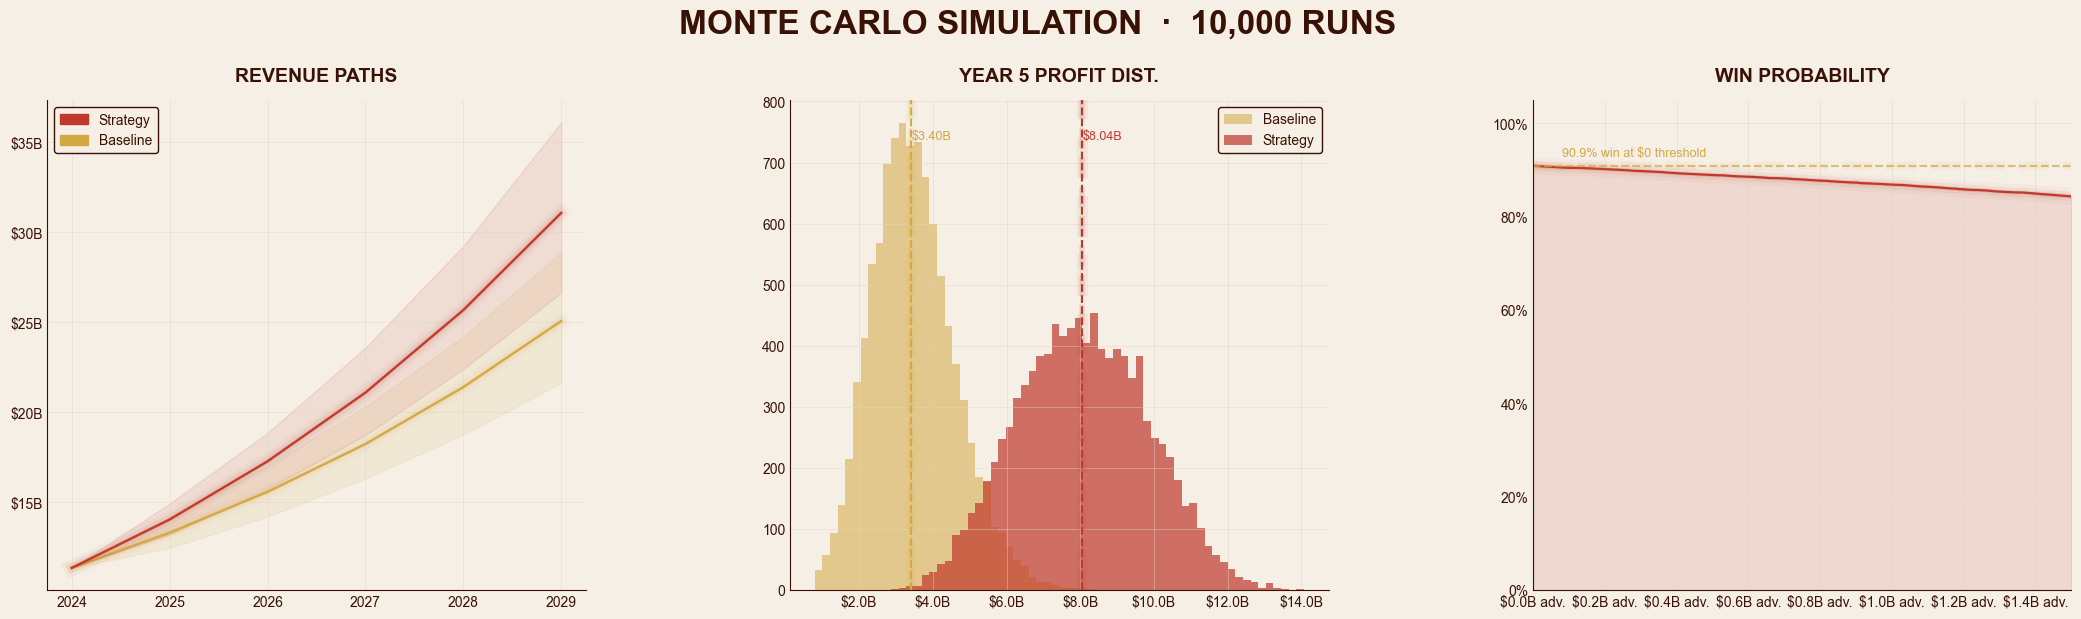

In [ ]:
# ═══════════════════════════════════════════════
# CELL A — MONTE CARLO GRAPHS
# ═══════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import numpy as np

BG    = '#F5EFE6'
PANEL = '#F5EFE6'
RED   = '#C0392B'
GOLD  = '#D4A843'
GREEN = '#D4A843'
CREAM = '#3A1205'


def glow(ax, x, y, color, lw=2, fill=False):
    for w, a in [(12, 0.03), (7, 0.07), (3, 0.15), (1.6, 1.0)]:
        ax.plot(x, y, color=color, lw=w, alpha=a)
    if fill:
        ax.fill_between(x, y, alpha=0.07, color=color)

strat_rev = results['base'][0]
strat_op  = results['base'][1]

fig, axes = plt.subplots(1, 3, figsize=(22, 7), facecolor=BG)
fig.subplots_adjust(left=0.05, right=0.97, top=0.84, bottom=0.14, wspace=0.38)
fig.suptitle('MONTE CARLO SIMULATION  ·  10,000 RUNS', fontsize=24,
             fontweight='bold', color=CREAM, y=0.97)

yr    = range(6)
xlbls = ['2024', '2025', '2026', '2027', '2028', '2029']

# ── 1. Revenue Growth Paths ──────────────────────────────────
ax = axes[0]
b_med = np.concatenate([[11.314], np.median(base_rev, axis=0)/1000])
s_med = np.concatenate([[11.314], np.median(strat_rev, axis=0)/1000])
b_p10 = np.concatenate([[11.314], np.percentile(base_rev, 10, axis=0)/1000])
b_p90 = np.concatenate([[11.314], np.percentile(base_rev, 90, axis=0)/1000])
s_p10 = np.concatenate([[11.314], np.percentile(strat_rev, 10, axis=0)/1000])
s_p90 = np.concatenate([[11.314], np.percentile(strat_rev, 90, axis=0)/1000])

ax.fill_between(yr, b_p10, b_p90, alpha=0.10, color=GOLD)
ax.fill_between(yr, s_p10, s_p90, alpha=0.10, color=RED)
glow(ax, yr, b_med, GOLD)
glow(ax, yr, s_med, RED)

ax.set_xticks(range(6))
ax.set_xticklabels(xlbls, fontsize=10)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'${v:.0f}B'))
ax.set_title('REVENUE PATHS', fontsize=14, color=CREAM, pad=14)
ax.tick_params(length=0)
ax.legend(handles=[mpatches.Patch(color=RED,  label='Strategy'),
                   mpatches.Patch(color=GOLD, label='Baseline')],
          frameon=True, fontsize=10, labelcolor=CREAM)

# ── 2. Year 5 Profit Distribution ───────────────────────────
ax = axes[1]
b_y5 = base_op[:, 4] / 1000
s_y5 = strat_op[:, 4] / 1000
bins = np.linspace(min(b_y5.min(), s_y5.min()), max(b_y5.max(), s_y5.max()), 65)

ax.hist(b_y5, bins=bins, color=GOLD, alpha=0.55, label='Baseline')
ax.hist(s_y5, bins=bins, color=RED,  alpha=0.70, label='Strategy')

for val, col in [(np.median(b_y5), GOLD), (np.median(s_y5), RED)]:
    for lw, a in [(8, 0.06), (4, 0.14), (1.5, 1.0)]:
        ax.axvline(val, color=col, lw=lw, alpha=a, linestyle='--')
    ax.text(val + 0.03, ax.get_ylim()[1] * 0.92,
            f'${val:.2f}B', color=col, fontsize=9, ha='left')

ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'${v:.1f}B'))
ax.set_title('YEAR 5 PROFIT DIST.', fontsize=14, color=CREAM, pad=14)
ax.tick_params(length=0)
ax.legend(frameon=True, fontsize=10, labelcolor=CREAM)

# ── 3. Win Probability Curve ─────────────────────────────────
ax = axes[2]
thresholds = np.linspace(0, 1.5, 300)
win_probs  = [(strat_rev[:, 4] - base_rev[:, 4] > t * 1000).mean()
              for t in thresholds]

ax.fill_between(thresholds, win_probs, alpha=0.12, color=RED)
glow(ax, thresholds, win_probs, RED)

win_0 = (strat_rev[:, 4] > base_rev[:, 4]).mean()
for lw, a in [(6, 0.08), (1.5, 0.7)]:
    ax.axhline(win_0, color=GREEN, lw=lw, alpha=a, linestyle='--')
ax.text(0.08, win_0 + 0.02, f'{win_0*100:.1f}% win at $0 threshold',
        color=GREEN, fontsize=9)

ax.set_xlim(0, 1.5)
ax.set_ylim(0, 1.05)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'${v:.1f}B adv.'))
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{v*100:.0f}%'))
ax.set_title('WIN PROBABILITY', fontsize=14, color=CREAM, pad=14)
ax.tick_params(length=0)

plt.show()


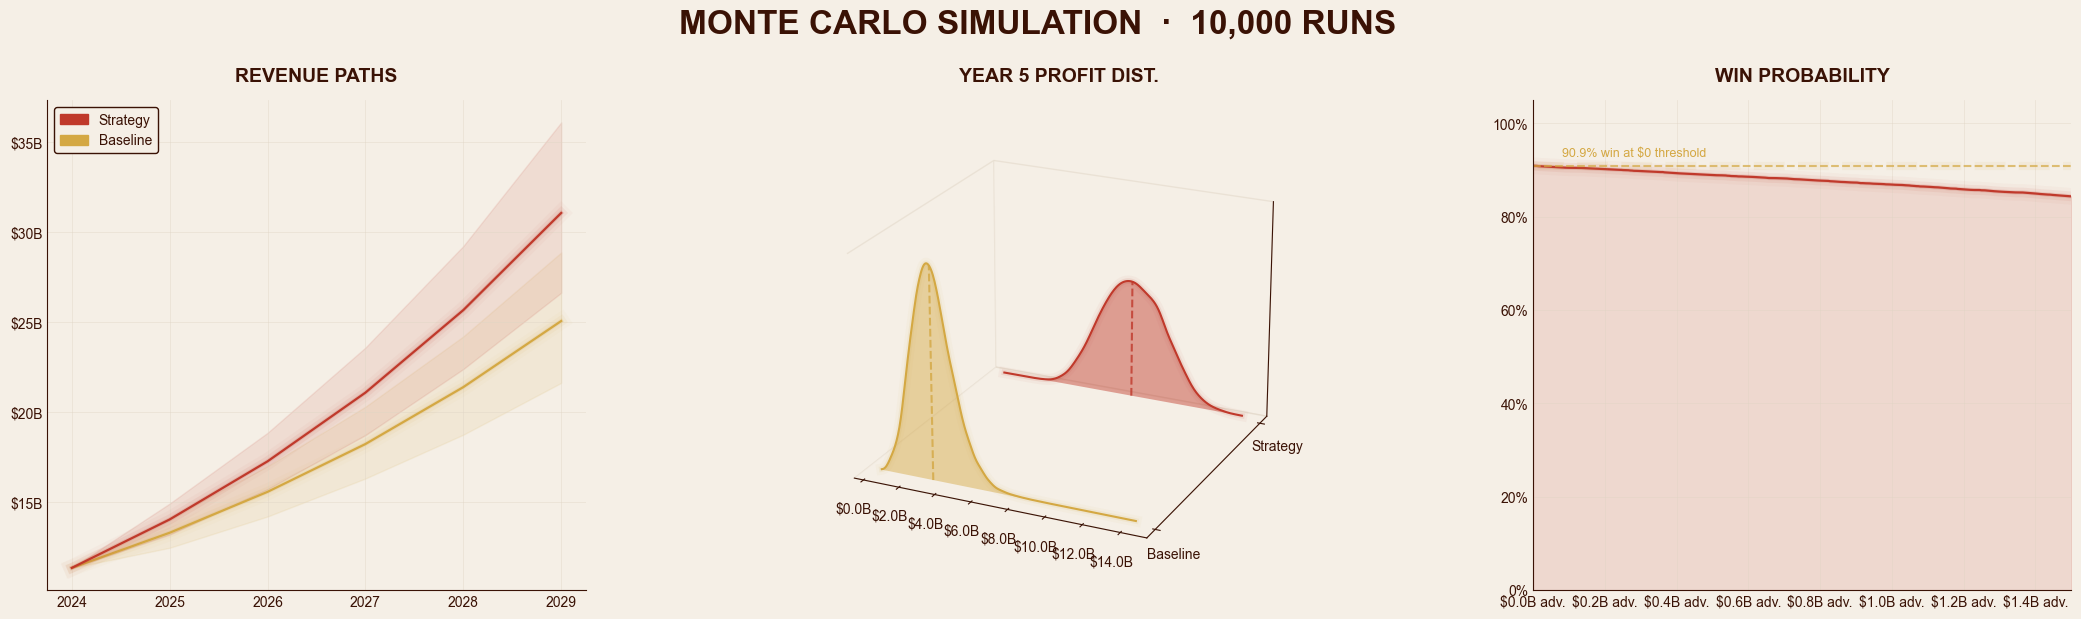

In [ ]:
# ═══════════════════════════════════════════════
# CELL A — MONTE CARLO GRAPHS
# ═══════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.stats import gaussian_kde

BG    = '#F5EFE6'
PANEL = '#F5EFE6'
RED   = '#C0392B'
GOLD  = '#D4A843'
GREEN = '#D4A843'
CREAM = '#3A1205'


def glow2d(ax, x, y, color, fill=False):
    for w, a in [(12, 0.03), (7, 0.07), (3, 0.15), (1.6, 1.0)]:
        ax.plot(x, y, color=color, lw=w, alpha=a)
    if fill:
        ax.fill_between(x, y, alpha=0.07, color=color)

def glow3d(ax, x, y_val, z, color):
    for w, a in [(8, 0.04), (4, 0.10), (1.5, 1.0)]:
        ax.plot(x, [y_val]*len(x), z, color=color, lw=w, alpha=a)

strat_rev = results['base'][0]
strat_op  = results['base'][1]

fig = plt.figure(figsize=(22, 7), facecolor=BG)
fig.subplots_adjust(left=0.05, right=0.97, top=0.84, bottom=0.14, wspace=0.38)
fig.suptitle('MONTE CARLO SIMULATION  ·  10,000 RUNS', fontsize=24,
             fontweight='bold', color=CREAM, y=0.97)

ax1 = fig.add_subplot(1, 3, 1)
ax2 = fig.add_subplot(1, 3, 2, projection='3d')
ax3 = fig.add_subplot(1, 3, 3)
axes = [ax1, ax2, ax3]

yr    = range(6)
xlbls = ['2024', '2025', '2026', '2027', '2028', '2029']

# ── 1. Revenue Growth Paths ──────────────────────────────────
ax = axes[0]
b_med = np.concatenate([[11.314], np.median(base_rev, axis=0)/1000])
s_med = np.concatenate([[11.314], np.median(strat_rev, axis=0)/1000])
b_p10 = np.concatenate([[11.314], np.percentile(base_rev, 10, axis=0)/1000])
b_p90 = np.concatenate([[11.314], np.percentile(base_rev, 90, axis=0)/1000])
s_p10 = np.concatenate([[11.314], np.percentile(strat_rev, 10, axis=0)/1000])
s_p90 = np.concatenate([[11.314], np.percentile(strat_rev, 90, axis=0)/1000])

ax.fill_between(yr, b_p10, b_p90, alpha=0.10, color=GOLD)
ax.fill_between(yr, s_p10, s_p90, alpha=0.10, color=RED)
glow2d(ax, yr, b_med, GOLD)
glow2d(ax, yr, s_med, RED)

ax.set_xticks(range(6))
ax.set_xticklabels(xlbls, fontsize=10)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'${v:.0f}B'))
ax.set_title('REVENUE PATHS', fontsize=14, color=CREAM, pad=14)
ax.tick_params(length=0)
ax.legend(handles=[mpatches.Patch(color=RED,  label='Strategy'),
                   mpatches.Patch(color=GOLD, label='Baseline')],
          frameon=True, fontsize=10, labelcolor=CREAM)

# ── 2. Year 5 Profit Distribution (3D Ridge) ─────────────────
ax = axes[1]

b_y5    = base_op[:, 4] / 1000
s_y5    = strat_op[:, 4] / 1000
x_range = np.linspace(min(b_y5.min(), s_y5.min()) - 0.3,
                      max(b_y5.max(), s_y5.max()) + 0.3, 300)

kde_b = gaussian_kde(b_y5, bw_method=0.18)
kde_s = gaussian_kde(s_y5, bw_method=0.18)
z_b   = kde_b(x_range)
z_s   = kde_s(x_range)

# Baseline ridge at y=0
verts_b = ([(x_range[0], 0, 0)]
           + [(x, 0, z) for x, z in zip(x_range, z_b)]
           + [(x_range[-1], 0, 0)])
poly_b = Poly3DCollection([verts_b])
poly_b.set_facecolor(GOLD)
poly_b.set_alpha(0.45)
poly_b.set_edgecolor('none')
ax.add_collection3d(poly_b)
glow3d(ax, x_range, 0, z_b, GOLD)

# Strategy ridge at y=1
verts_s = ([(x_range[0], 1, 0)]
           + [(x, 1, z) for x, z in zip(x_range, z_s)]
           + [(x_range[-1], 1, 0)])
poly_s = Poly3DCollection([verts_s])
poly_s.set_facecolor(RED)
poly_s.set_alpha(0.45)
poly_s.set_edgecolor('none')
ax.add_collection3d(poly_s)
glow3d(ax, x_range, 1, z_s, RED)

# Median markers
for val, col, y_pos in [(np.median(b_y5), GOLD, 0), (np.median(s_y5), RED, 1)]:
    ax.plot([val, val], [y_pos, y_pos], [0, kde_b(val)[0] if col==GOLD else kde_s(val)[0]],
            color=col, lw=1.5, alpha=0.8, linestyle='--')

ax.set_yticks([0, 1])
ax.set_yticklabels(['Baseline', 'Strategy'], color=CREAM, fontsize=10)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'${v:.1f}B'))
ax.set_title('YEAR 5 PROFIT DIST.', fontsize=14, color=CREAM, pad=14)
ax.view_init(elev=22, azim=-65)
ax.set_facecolor(PANEL)
ax.xaxis.pane.set_facecolor(PANEL)
ax.yaxis.pane.set_facecolor(PANEL)
ax.zaxis.pane.set_facecolor(PANEL)
ax.xaxis.pane.set_edgecolor('#E0D5C5')
ax.yaxis.pane.set_edgecolor('#E0D5C5')
ax.zaxis.pane.set_edgecolor('#E0D5C5')
ax.tick_params(colors=CREAM, length=0)
ax.set_zticks([])
ax.grid(False)

# ── 3. Win Probability Curve ─────────────────────────────────
ax = axes[2]
thresholds = np.linspace(0, 1.5, 300)
win_probs  = [(strat_rev[:, 4] - base_rev[:, 4] > t * 1000).mean()
              for t in thresholds]

ax.fill_between(thresholds, win_probs, alpha=0.12, color=RED)
glow2d(ax, thresholds, win_probs, RED)

win_0 = (strat_rev[:, 4] > base_rev[:, 4]).mean()
for lw, a in [(6, 0.08), (1.5, 0.7)]:
    ax.axhline(win_0, color=GREEN, lw=lw, alpha=a, linestyle='--')
ax.text(0.08, win_0 + 0.02, f'{win_0*100:.1f}% win at $0 threshold',
        color=GREEN, fontsize=9)

ax.set_xlim(0, 1.5)
ax.set_ylim(0, 1.05)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'${v:.1f}B adv.'))
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{v*100:.0f}%'))
ax.set_title('WIN PROBABILITY', fontsize=14, color=CREAM, pad=14)
ax.tick_params(length=0)

plt.show()


In [ ]:
print(f"Baseline Y5 FCF median:  ${np.median(base_fcf[:, 4])/1000:.2f}B")
print(f"Strategy Y5 FCF median:  ${np.median(strat_fcf[:, 4])/1000:.2f}B")
print(f"Baseline P50 price:      ${np.median(prices_baseline_fixed):.2f}")
print(f"Strategy P50 price:      ${np.median(prices_strategy):.2f}")

Baseline Y5 FCF median:  $1.72B
Strategy Y5 FCF median:  $4.07B
Baseline P50 price:      $36.00
Strategy P50 price:      $46.82
